## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import sys
import io
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "3"
dataset_type_du = f"{agrupamento}_days_concat"
#validation_method = 'split'

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = "Resultados_PSO/pso_concat/3_days/pesos/teste_1"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = "Resultados_PSO/pso_concat/3_days/pesos/teste_3"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

diretorio_avaliacao_teste_0 = "Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_0"
os.makedirs(diretorio_avaliacao_teste_0, exist_ok=True)

diretorio_avaliacao_teste_1 = "Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1"
os.makedirs(diretorio_avaliacao_teste_1, exist_ok=True)

diretorio_avaliacao_teste_2 = "Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2"
os.makedirs(diretorio_avaliacao_teste_2, exist_ok=True)

diretorio_avaliacao_teste_3 = "Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3"
os.makedirs(diretorio_avaliacao_teste_3, exist_ok=True)

diretorio_avaliacao_teste_4 = "Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type_du]['timesteps'] + config['datasets'][dataset_type_du]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
#print(validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [8]:
def save_function_output(func, *args, output_file, output_dir, **kwargs):
    # Redireciona stdout para capturar os prints
    old_stdout = sys.stdout
    new_stdout = io.StringIO()
    sys.stdout = new_stdout
    
    try:
        # Executa a função e captura sua saída
        func(*args, **kwargs)
    finally:
        # Restaura stdout e captura a saída
        sys.stdout = old_stdout
        output = new_stdout.getvalue()
        
        # Cria o diretório se não existir
        os.makedirs(output_dir, exist_ok=True)
        
        # Caminho completo para o arquivo de saída
        save_path = os.path.join(output_dir, output_file)
        
        # Salva a saída em um arquivo
        with open(save_path, 'w') as f:
            f.write(output)
        print(f"Output salvo em: {save_path}")

In [9]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [10]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [11]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [12]:
def create_model(config, dataset_type, X, y, validation_method, k_folds):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    # Aplicar o método de validação
    if validation_method == 'split':
        # Usar validação por divisão
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        callbacks=[early_stopping])

    elif validation_method == 'k-fold':
    # Usar validação k-fold
    
        kf = KFold(n_splits=min(k_folds, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
        for train_index, val_index in kf.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]
            history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                            callbacks=[early_stopping])
        
        # Ajuste do gráfico para começar em 1
        epochs_range = range(1, len(history.history['loss']) + 1)

        plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
        plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    return model

In [13]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [14]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [15]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [16]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    #pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    #pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    #lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    #lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [17]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    #lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    #print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    #lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    #print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [19]:
# Automatizar os splits de treino/teste
current_filename = None
resultados = []  # Para armazenar os resultados de cada execução
def salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation):
    global current_filename, resultados
    
    # Se o nome do arquivo mudou, salvar os resultados e reiniciar a lista
    if current_filename != diretorio:
        # Atualiza o nome do arquivo atual e reinicia a lista de resultados
        current_filename = diretorio
        resultados = []  # Reinicia a lista de resultados
    
    # Armazenar os resultados
    resultados.append({
        'valid': validation,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'accur 2%': acuracia_2,
        'accur 5%': acuracia_5,
        'accur 10%': acuracia_10,
        'Erro %. acum 3d': err_perc_acum_30dias,
        'Erro %. acum 60d': err_perc_acum_60dias,
        'Erro %. acum 90d': err_perc_acum_90dias,
        'Erro %. acum 1ºm': err_perc_acum_pri_mes,
        'Erro %. acum 2ºm': err_perc_acum_seg_mes,
        'Erro %. acum 3ºm': err_perc_acum_ter_mes
         
        
    })
            
    # Salvar os resultados em um arquivo CSV
    results_df = pd.DataFrame(resultados)
    results_df.to_csv(f'{diretorio}/results.csv', index=False)
    print('Terminada sequencia de testes')

In [20]:
def avaliacao_multistep(janela_real, janela_prevista, diretorio, validation):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    # print(janela_real)
    # print(" ")
    # print(janela_prevista)
    # print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)
    print(" ")
    
    acumulado_1mes_real = janela_real[:10].sum()
    acumulado_1e2mes_real = janela_real[:20].sum()
    acumulado_1e2e3mes_real = janela_real[:30].sum()
    acumulado_2mes_real = janela_real[10:20].sum()
    acumulado_3mes_real = janela_real[20:30].sum()

    acumulado_1mes_pred = janela_prevista[:10].sum()
    acumulado_1e2mes_pred = janela_prevista[:20].sum()
    acumulado_1e2e3mes_pred = janela_prevista[:30].sum()
    acumulado_2mes_pred = janela_prevista[10:20].sum()
    acumulado_3mes_pred = janela_prevista[20:30].sum()
    
    err_perc_acum_30dias = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_60dias = round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2)
    err_perc_acum_90dias = round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2)
    err_perc_acum_pri_mes = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_seg_mes = round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2)
    err_perc_acum_ter_mes = round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2)

    print("Erro %. acum 30d:", err_perc_acum_30dias,"%")
    print("Erro %. acum 60d:", err_perc_acum_60dias,"%")
    print("Erro %. acum 90d:", err_perc_acum_90dias,"%")
    print(" ")
    print("Erro %. acum 1ºm:", err_perc_acum_pri_mes,"%")
    print("Erro %. acum 2ºm:", err_perc_acum_seg_mes,"%")
    print("Erro %. acum 3ºm:", err_perc_acum_ter_mes,"%")
    
    salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation)
    
    return

In [21]:
def results(model, validation_dataset_scaled, validation_method, diretorio, validation):
    pred = model.predict(validation_dataset_scaled.iloc[0])
    y_pred_rescaled = scalers[4].inverse_transform(pred)
    y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
    duas_unas_validation_rescaled = scalers[4].inverse_transform(validation_dataset_scaled[1:])

    plt.figure(figsize=(14,6))
    plt.plot(validation_dataset_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
    plt.plot(validation_dataset_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
    plt.yticks(np.arange(0,80000,step=10000))
    plt.title("DATASET TESTE 2")

        # Nome do arquivo incluindo a variável 'validation_method'
    if validation_method == 'k-fold':
        file_name = f'prediction_plot_with_method_{validation_method}_{validation}.png'
    else:
        file_name = f'prediction_plot_with_method_{validation_method}_.png'

    # Caminho completo para salvar o arquivo
    save_path = os.path.join(diretorio, file_name)

    # Salvar o plot
    plt.savefig(save_path)
    plt.show()
    
    
    #avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio, validation)

    # Nome do arquivo incluindo a variável 'validation_method'
    if validation_method == 'k-fold':
        output_file = f'avaliacao_with_method_{validation_method}_{validation}.txt'
    else:
        output_file = f'avaliacao_with_method_{validation_method}.txt'
    
    save_function_output(avaliacao_multistep, 
                        duas_unas_validation_rescaled, 
                        y_pred_rescaled,
                        diretorio,
                        validation, 
                        output_file = output_file, 
                        output_dir=diretorio)

In [22]:
# Função para criar e treinar o modelo
def train_model(X, y, validation_method, k):
    model = create_model(config, dataset_type_du, X, y, validation_method, k)
    learning_rate = 0.005

    optimizer = config['datasets'][dataset_type_du]['optimizer']
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    loss_function = config['datasets'][dataset_type_du]["loss_function"]
    loss = wmae if loss_function == "wmae" else wmse

    model.compile(optimizer=opt, loss=loss)
    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type_du]["patience"], restore_best_weights=True)

    if k:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        val_losses = []

        for train_index, val_index in kf.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'],
                                epochs=100000, validation_data=(X_val, y_val), callbacks=[early_stopping])
            val_losses.append(min(history.history['val_loss']))

        avg_val_loss = np.mean(val_losses)
        print(f"Average Validation Loss for k={k}: {avg_val_loss}")

    else:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'],
                            epochs=100000, validation_data=(X_test, y_test), callbacks=[early_stopping])

        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return model


In [23]:
#from tensorflow.keras.initializers import HeNormal
def transfer_learning_model(config, model, diretorio_pesos, diretorio_resultados, teste, validation_method, k):
    
    # Salvamento dos pesos após primeiro treinamento
    pesos_treinamento = model.get_weights()
    pesos_LSTM1 = model.layers[0].get_weights()
    pesos_LSTM2 = model.layers[2].get_weights()
    #pesos_LSTM3 = model.layers[4].get_weights()
    pesos_DENSE = model.layers[4].get_weights()

    # Salvar pesos de cada camada LSTM em arquivos .npz
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM1)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM2)
    #np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM3)
    np.savez(os.path.join(diretorio_pesos, f'pesos_DENSE_{teste}_{validation_method}_{k}.npz'), *pesos_DENSE)

    # Para salvar os pesos do modelo completo
    np.savez(os.path.join(diretorio_pesos, f'pesos_modelo_{teste}_{validation_method}_{k}.npz'), *pesos_treinamento)

    # # Carregar pesos do arquivo .npz
    # pesos_carregados_LSTM1 = np.load(os.path.join(diretorio, f'pesos_LSTM1_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM2 = np.load(os.path.join(diretorio, f'pesos_LSTM2_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM3 = np.load(os.path.join(diretorio, f'pesos_LSTM3_{teste}_{validation_method}.npz'))
    
    
    X, y = create_dataset(scaled_datasets[4], config['datasets'][dataset_type_du]['timesteps'], config['datasets'][dataset_type_du]['output_horizon'])
    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_ft = Sequential()

    for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
        model_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model_ft.add(Dropout(config['datasets'][dataset_type_du]['dropout']))

    model_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type_du]['activation']))

    model_ft.summary()
    
    
    # Caminho dos pesos salvos
    caminho_LSTM1 = os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM2 = os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM3 = os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz')

    carregar_e_aplicar_pesos(model_ft, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3)
        
    congelar_camadas(model_ft)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

    learning_rate = 0.005

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()
    
    descongelar_camadas(model_ft)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

    learning_rate = 0.0008

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()

    results(model_ft, duas_unas_validation_scaled, validation_method, diretorio_resultados, k)

## **TESTE 00A**
Dataset Duas Unas.

Teste tradicional do modelo sem otimização PSO e treinado apenas pelo dataset Duas Unas.

In [24]:
### DATASETS PARA TESTE 00A ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0A = concatenate_selected_datasets(scaled_datasets, indices)

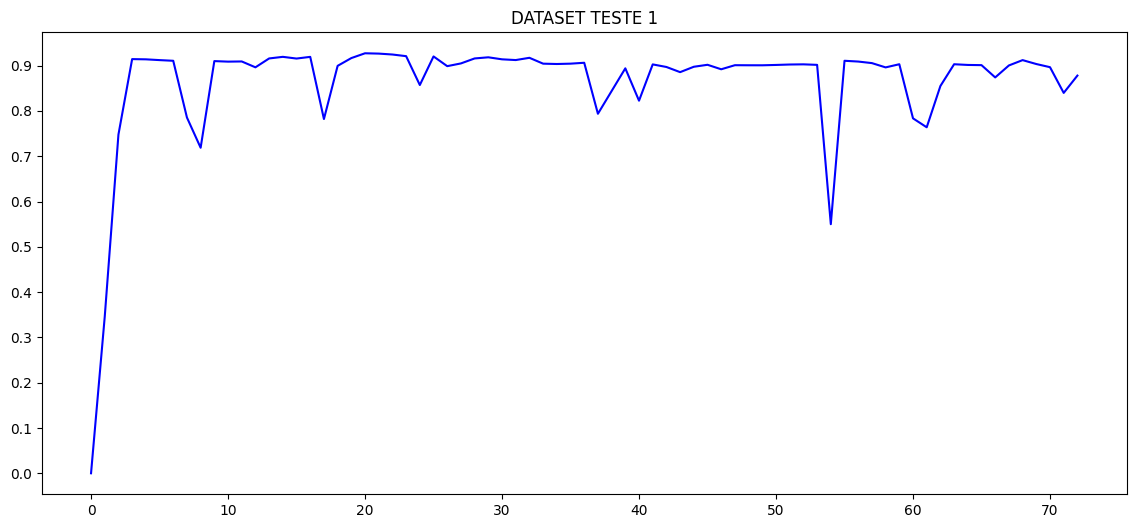

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0A, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (43, 1)
y shape (43, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 100)         │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         3,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,230 (485.27 KB)

 Trainable params: 124,230 (485.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 451ms/step - loss: 0.7730 - val_loss: 0.6231
Epoch 2/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.5903 - val_loss: 0.2543
Epoch 3/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.2088 - val_loss: 0.0756
Epoch 4/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1359 - val_loss: 0.0974
Epoch 5/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0848 - val_loss: 0.0083
Epoch 6/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0297 - val_loss: 0.0471
Epoch 7/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0659 - val_loss: 0.0374
Epoch 8/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0435 - val_loss: 0.0094
Epoch 9/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0209 - val_loss: 0.0151
Epoch 10/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0324 - val_loss: 0.0158
Epoch 11/100000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0293 - val_loss: 0.0052
Epoch 12/100000
3/3 ━━━━━━━━━━━━━━━━━━━

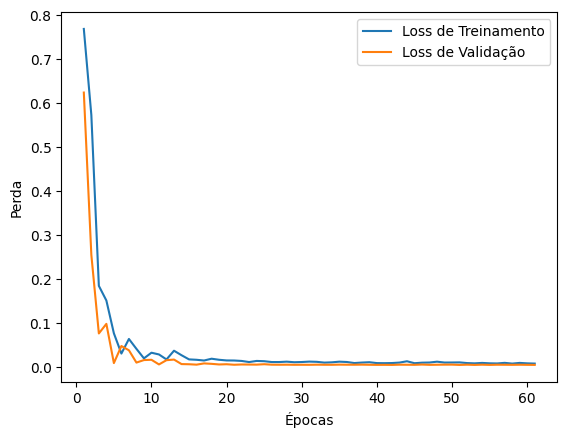

In [26]:
from tensorflow.keras.losses import MeanSquaredError
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0, y_0 = create_dataset(dataset_test_0A, timesteps, output_steps)
X_0 = X_0.reshape(X_0.shape[0], X_0.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.2, random_state=42)

model0A = Sequential()

                                                          #X_train.shape[1]
model0A.add(LSTM(100,return_sequences=True, input_shape=(X_0.shape[1], 1))) # Apenas a primeira camada informa input_shape. As demais fazem inferência
model0A.add(Dropout(0.3)) # Taxa de atenuação aplicada à saída para evitar overfitting - Elimina aleatoriamente alguns neurônios

# model0A.add(LSTM(100,return_sequences=True))
# model0A.add(Dropout(0.3))

model0A.add(LSTM(100,return_sequences=False)) #Anteriormente era FALSE. Foi alterado devido à adição da camada Attention
model0A.add(Dropout(0.3))

model0A.add(Dense(30)) # Dense - Camada totalmente conectada com dimensionalidade de saída igual a 1

model0A.summary() # Printa um sumário da rede

model0A.compile(optimizer=Adam(learning_rate=0.01), loss=MeanSquaredError)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True)

history = model0A.fit(X_train, y_train, batch_size=16, epochs=100000, validation_data=(X_test, y_test), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


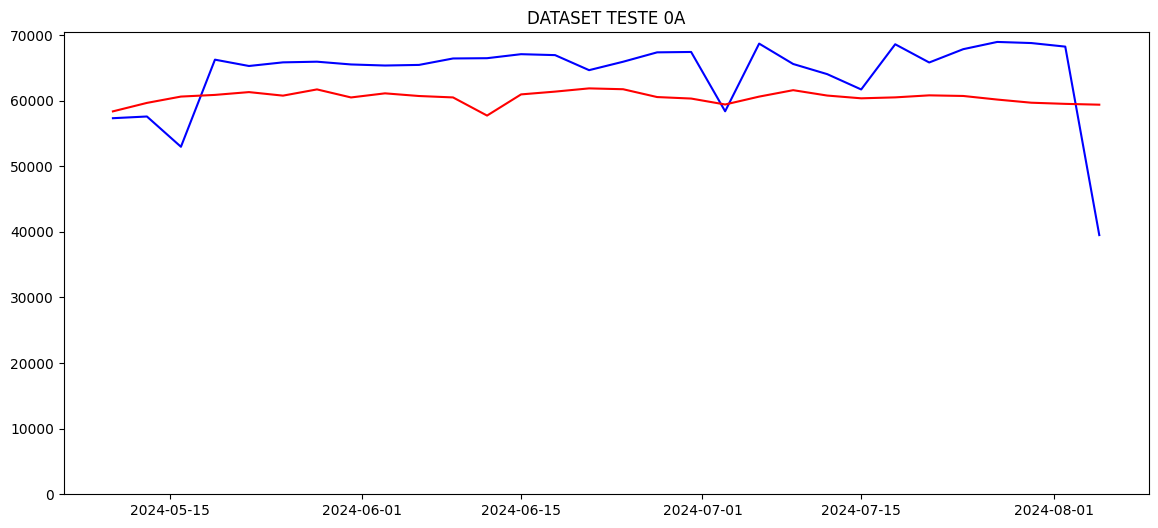

In [27]:
pred = model0A.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 0A")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0A.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [28]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled, 
                     y_pred_rescaled, 
                     diretorio_avaliacao_teste_0,
                     'split_0A',
                     output_file='avaliacao_test_0A.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_0\avaliacao_test_0A.txt


## **TESTE 00B**
Dataset Duas Unas.

Teste tradicional do modelo otimizado com PSO e treinado apenas pelo dataset Duas Unas.

In [24]:
### DATASETS PARA TESTE 00B ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [4]
dataset_test_0 = concatenate_selected_datasets(scaled_datasets, indices)

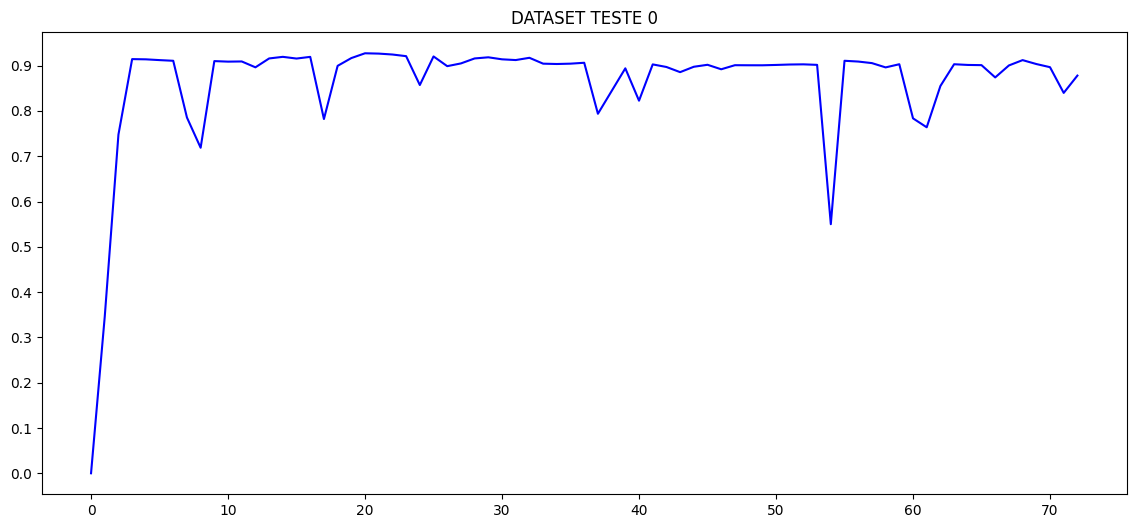

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_0, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 0")
plt.show()

X shape (43, 1)
y shape (43, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - loss: 0.8839 - val_loss: 0.8607
Epoch 2/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - loss: 0.8639 - val_loss: 0.8356
Epoch 3/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step - loss: 0.8389 - val_loss: 0.8101
Epoch 4/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.8150 - val_loss: 0.7800
Epoch 5/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.7827 - val_loss: 0.7370
Epoch 6/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.7411 - val_loss: 0.6746
Epoch 7/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.6765 - val_loss: 0.5796
Epoch 8/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.5786 - val_loss: 0.4345
Epoch 9/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.4274 - val_loss: 0.2268
Epoch 10/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.2382 - val_loss: 0.1314
Epoch 11/100000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 0.1650 - val_loss: 0.1485
Epoch 12/100000
1/1 ━━━━━━━━━━━━━

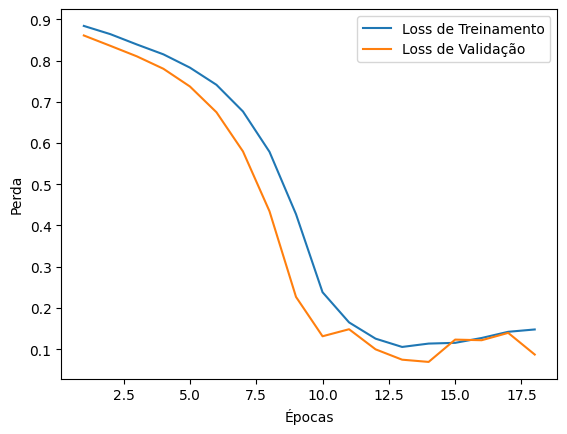

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_0, y_0 = create_dataset(dataset_test_0, timesteps, output_steps)
X_0 = X_0.reshape(X_0.shape[0], X_0.shape[1], 1)
X_train, X_test, y_train, y_test = train_test_split(X_0, y_0, test_size=0.6, random_state=42)

model0 = Sequential()

for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
    model0.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                    #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                    return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X_0.shape[1], 1)))

    model0.add(Dropout(config['datasets'][dataset_type_du]['dropout']))

model0.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                    #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                    #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                    activation=config['datasets'][dataset_type_du]['activation']))

model0.summary()

# Configurar o otimizador
optimizer = config['datasets'][dataset_type_du]['optimizer']
    
if optimizer == 'adam':
    opt = Adam(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
elif optimizer == 'rmsprop':
    opt = RMSprop(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])
else:
    opt = SGD(learning_rate=config['datasets'][dataset_type_du]['learning_rate'])

# Configurar a função de perda
loss_function = config['datasets'][dataset_type_du]["loss_function"]

if loss_function == "wmae":
    loss = wmae
elif loss_function == "wmse":
    loss = wmse

model0.compile(optimizer=opt, loss=loss)

early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type_du]['patience'], restore_best_weights=True)

history = model0.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                callbacks=[early_stopping])
    
# Ajuste do gráfico para começar em 1
epochs_range = range(1, len(history.history['loss']) + 1)

plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


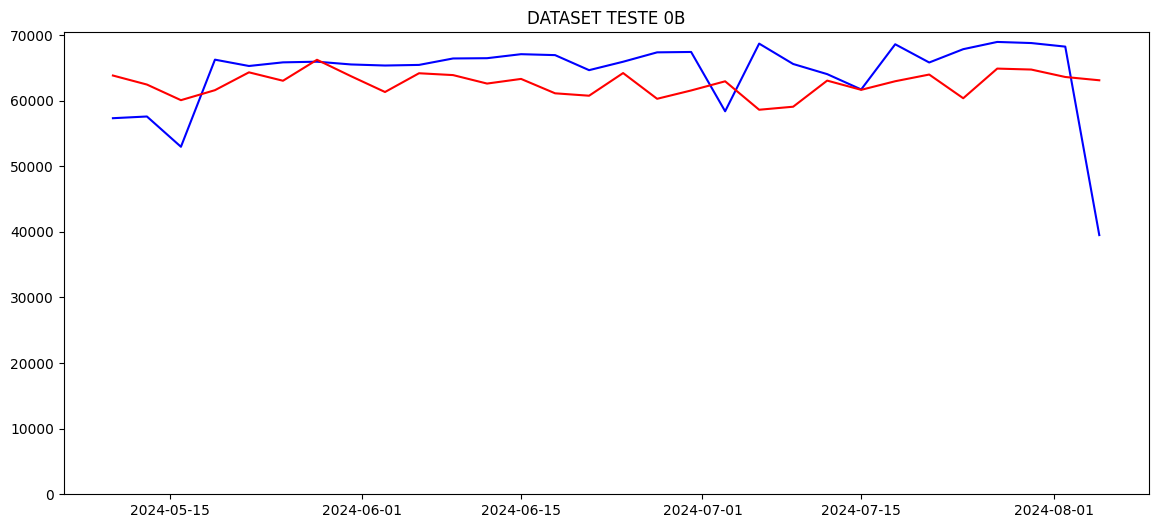

In [27]:
pred = model0.predict(duas_unas_validation_scaled.iloc[0])
y_pred_rescaled = scalers[4].inverse_transform(pred)
y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

plt.figure(figsize=(14,6))
plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
plt.yticks(np.arange(0,80000,step=10000))
plt.title("DATASET TESTE 0B")

# Nome do arquivo incluindo a variável 'name'
file_name = 'prediction_plot_teste_0B.png'

# Caminho completo para salvar o arquivo
save_path = os.path.join(diretorio_avaliacao_teste_0, file_name)

# Salvar o plot
plt.savefig(save_path)
plt.show()

In [28]:
#avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio_avaliacao_teste_0, 'split')

save_function_output(avaliacao_multistep, 
                     duas_unas_validation_rescaled, 
                     y_pred_rescaled, 
                     diretorio_avaliacao_teste_0,
                     'split_0B',
                     output_file='avaliacao_teste_0B.txt', 
                     output_dir=diretorio_avaliacao_teste_0)

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_0\avaliacao_teste_0B.txt


## **TESTE 01**
Prata I, II, III e Duas Unas.
Ações a serem testadas:

0. Validar se a técnica de TL que envolve congelamento de camadas é reconhecido e amplamente utilizado;
1. Padronizar cada dataset em separado (Prata I, II, III);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 01 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [1, 2, 3]
dataset_test_1 = concatenate_selected_datasets(scaled_datasets, indices)

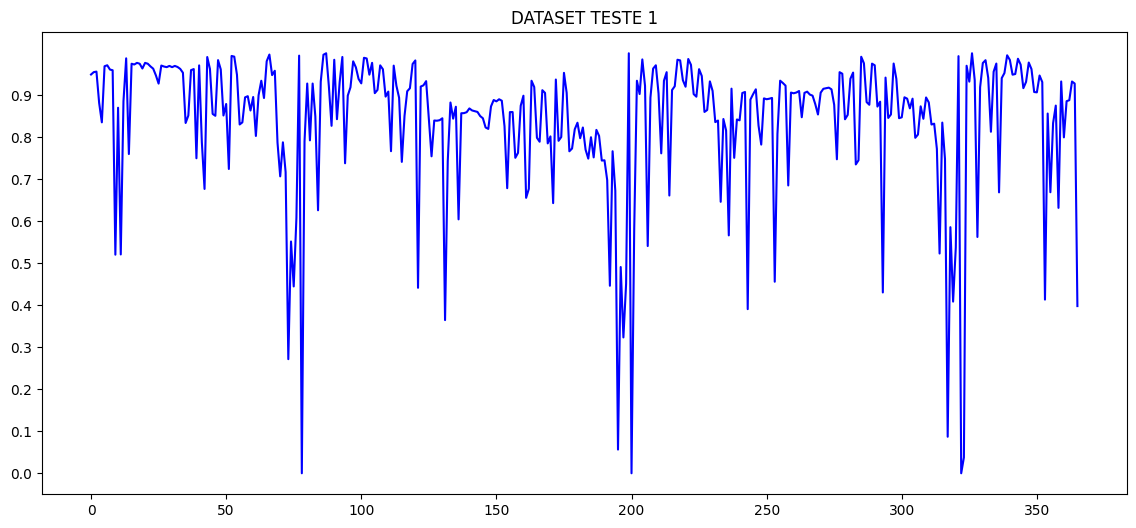

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_1, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_1, y_1 = create_dataset(dataset_test_1, timesteps, output_steps)
X_1 = X_1.reshape(X_1.shape[0], X_1.shape[1], 1)

#model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)

X shape (336, 1)
y shape (336, 30)



Training with k-fold cross-validation, k=2


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - loss: 0.7572 - val_loss: 0.3030
Epoch 2/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.2414 - val_loss: 0.1113
Epoch 3/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1789 - val_loss: 0.1116
Epoch 4/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1776 - val_loss: 0.1105
Epoch 5/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1803 - val_loss: 0.1149
Epoch 6/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1666 - val_loss: 0.1110
Epoch 7/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1679 - val_loss: 0.1086
Epoch 8/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1648 - val_loss: 0.1086
Epoch 9/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1693 - val_loss: 0.1114
Epoch 10/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1628 - val_loss: 0.1074
Epoch 11/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1590 - val_loss: 0.1107
Epoch 12/100000
9/9 ━━━━━━━━━━━━━━━━━━━━

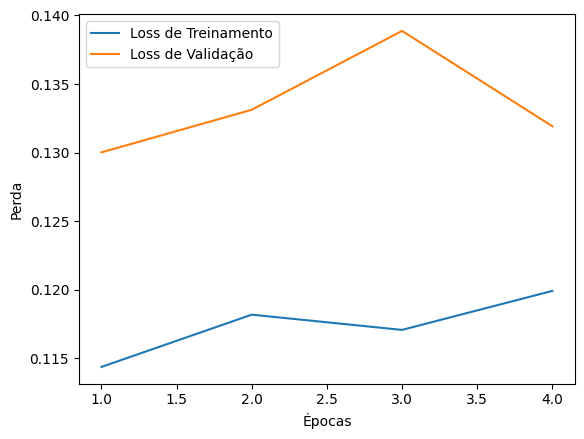

Epoch 1/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - loss: 0.1480 - val_loss: 0.1161
Epoch 2/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1357 - val_loss: 0.1164
Epoch 3/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1367 - val_loss: 0.1272
Epoch 4/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1380 - val_loss: 0.1165
Epoch 5/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1425 - val_loss: 0.1165
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1345 - val_loss: 0.1325
Epoch 2/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1350 - val_loss: 0.1166
Epoch 3/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1349 - val_loss: 0.1182
Epoch 4/100000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1352 - val_loss: 0.1206
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Average Validation Loss for k=2: 0.116344280540943

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 872ms/step - loss: 0.8792 - val_loss: 0.8374
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.8350 - val_loss: 0.7861
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.7820 - val_loss: 0.7141
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7097 - val_loss: 0.6094
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.6013 - val_loss: 0.4650
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4614 - val_loss: 0.2856
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.2753 - val_loss: 0.1000
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1097 - val_loss: 0.0675
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0968 - val_loss: 0.0499
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0842 - val_loss: 0.0911
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1084 - val_

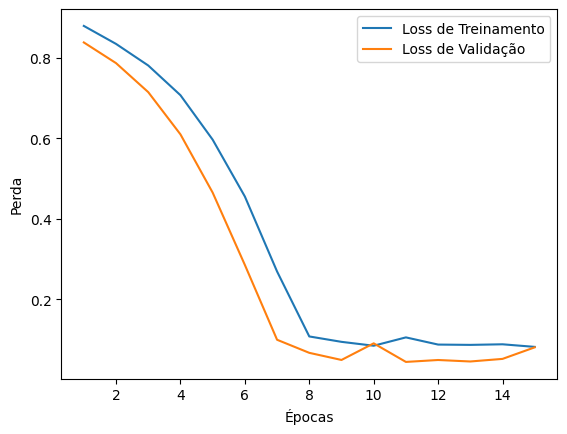

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 919ms/step - loss: 0.0847 - val_loss: 0.0421
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0847 - val_loss: 0.0392
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0774 - val_loss: 0.0451
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0805 - val_loss: 0.0362
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0758 - val_loss: 0.0368
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0787 - val_loss: 0.0455
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0755 - val_loss: 0.0372
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0854 - val_loss: 0.0359
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0807 - val_loss: 0.0393
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0761 - val_loss: 0.0371
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0708 - val_loss: 0.0378
Epoch 12/100000


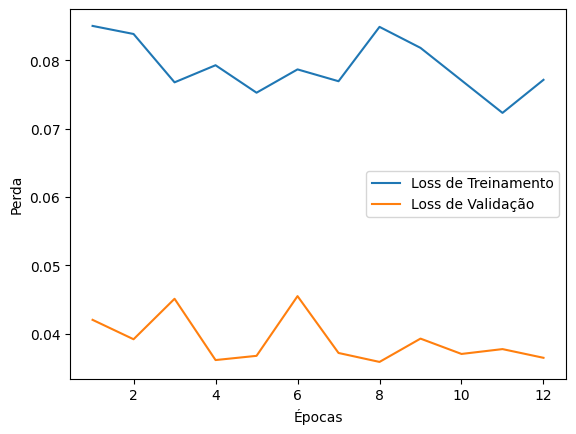

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


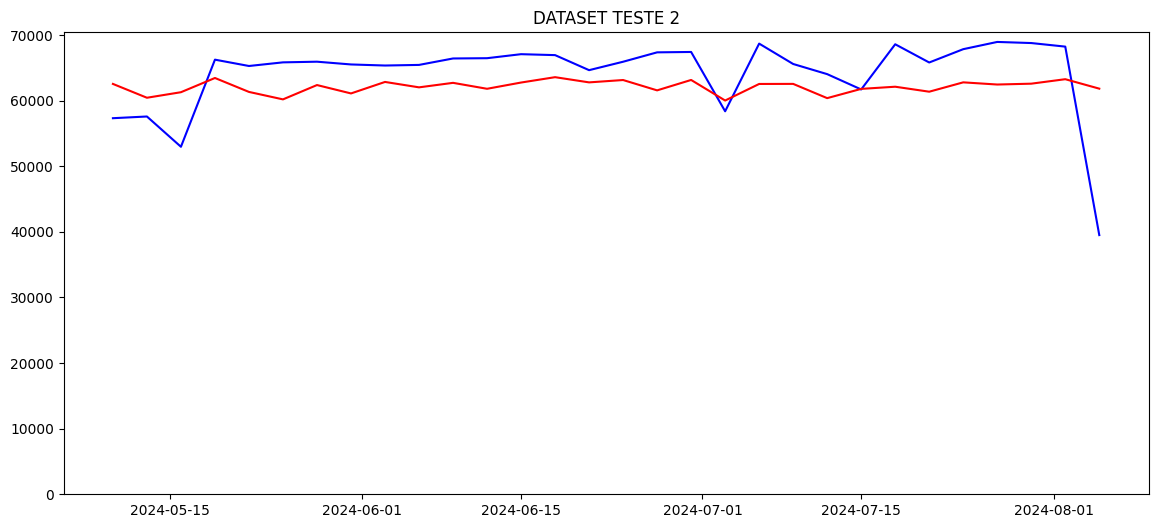

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_2.txt

Training with k-fold cross-validation, k=3


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.7073 - val_loss: 0.1266
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1668 - val_loss: 0.1232
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1599 - val_loss: 0.1458
Epoch 4/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1503 - val_loss: 0.1724
Epoch 5/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1600 - val_loss: 0.1287
Epoch 6/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1496 - val_loss: 0.1219
Epoch 7/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1515 - val_loss: 0.1408
Epoch 8/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1445 - val_loss: 0.1139
Epoch 9/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1484 - val_loss: 0.1197
Epoch 10/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1404 - val_loss: 0.1798
Epoch 11/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1454 - val_loss: 0.1153
Epoch 12/100000
12/

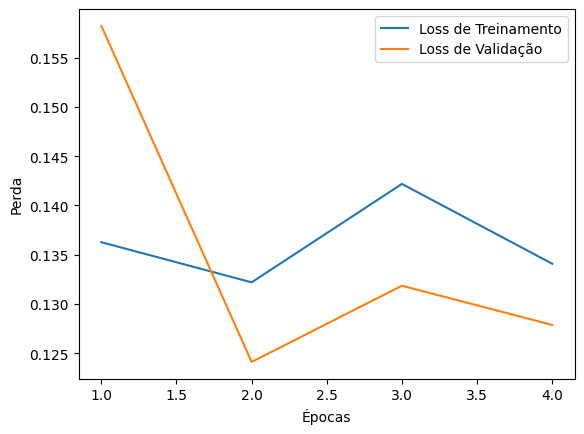

Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - loss: 0.1589 - val_loss: 0.1214
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1354 - val_loss: 0.1218
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1392 - val_loss: 0.1206
Epoch 4/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1356 - val_loss: 0.1569
Epoch 5/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1429 - val_loss: 0.1209
Epoch 6/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1346 - val_loss: 0.1208
Epoch 7/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1305 - val_loss: 0.1211
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1390 - val_loss: 0.1204
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1406 - val_loss: 0.1149
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1337 - val_loss: 0.1228
Epoch 4/100000
12/12 ━━━━━━

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 806ms/step - loss: 0.8787 - val_loss: 0.8328
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8301 - val_loss: 0.7784
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.7731 - val_loss: 0.6989
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.6902 - val_loss: 0.5831
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.5684 - val_loss: 0.4268
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4153 - val_loss: 0.2346
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2165 - val_loss: 0.0741
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0988 - val_loss: 0.0553
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0789 - val_loss: 0.0454
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0776 - val_loss: 0.0468
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0861 - val_l

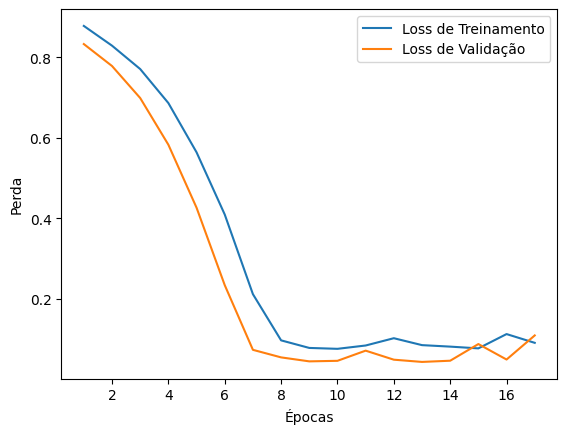

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 782ms/step - loss: 0.0826 - val_loss: 0.0540
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0796 - val_loss: 0.0381
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0762 - val_loss: 0.0570
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0731 - val_loss: 0.0410
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0821 - val_loss: 0.0343
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0791 - val_loss: 0.0351
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0781 - val_loss: 0.0374
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0805 - val_loss: 0.0354
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0755 - val_loss: 0.0420
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.


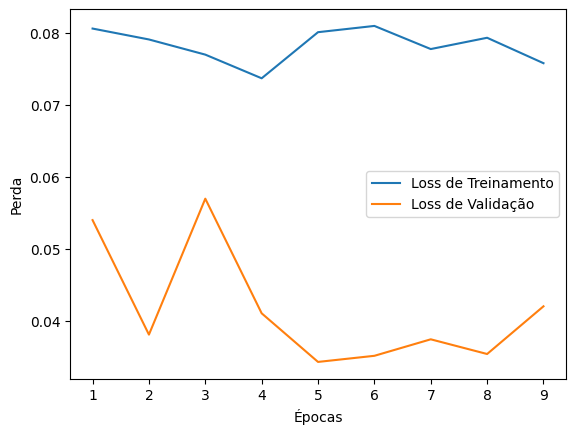

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


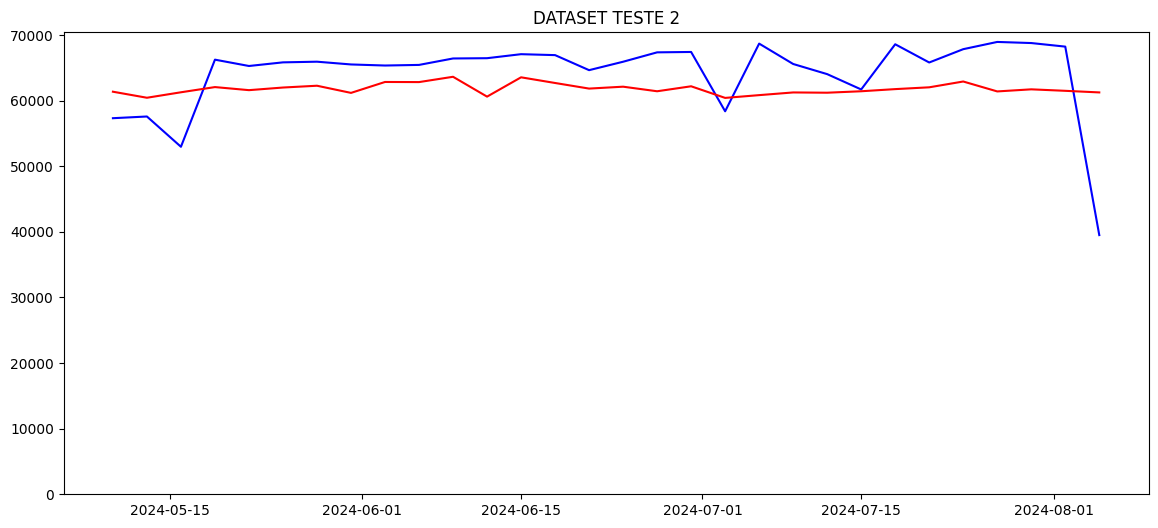

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_3.txt

Training with k-fold cross-validation, k=4


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.6876 - val_loss: 0.1992
Epoch 2/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1780 - val_loss: 0.1534
Epoch 3/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1632 - val_loss: 0.1213
Epoch 4/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1518 - val_loss: 0.2001
Epoch 5/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1602 - val_loss: 0.1770
Epoch 6/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1573 - val_loss: 0.1801
Epoch 7/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1507 - val_loss: 0.1391
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1636 - val_loss: 0.0988
Epoch 2/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1696 - val_loss: 0.0915
Epoch 3/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1598 - val_loss: 0.0877
Epoch 4/100000
13/13 ━━━━━━

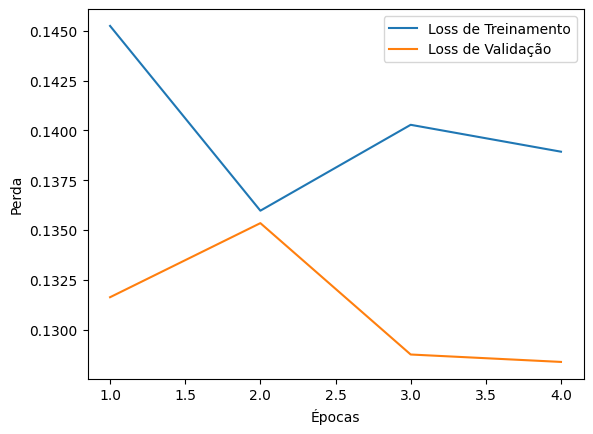

Epoch 1/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - loss: 0.1545 - val_loss: 0.1452
Epoch 2/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1383 - val_loss: 0.1376
Epoch 3/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1364 - val_loss: 0.1677
Epoch 4/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1386 - val_loss: 0.1298
Epoch 5/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1343 - val_loss: 0.1515
Epoch 6/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1324 - val_loss: 0.1233
Epoch 7/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1309 - val_loss: 0.1450
Epoch 8/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1347 - val_loss: 0.1304
Epoch 9/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1302 - val_loss: 0.1234
Epoch 10/100000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1299 - val_loss: 0.1294
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 1/100000
13/13 ━━━━

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 778ms/step - loss: 0.8790 - val_loss: 0.8323
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.8296 - val_loss: 0.7792
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7747 - val_loss: 0.7050
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.6995 - val_loss: 0.5971
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.5923 - val_loss: 0.4519
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4363 - val_loss: 0.2654
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.2628 - val_loss: 0.0778
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0908 - val_loss: 0.0461
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0938 - val_loss: 0.0486
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0783 - val_loss: 0.0467
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0866 - val_l

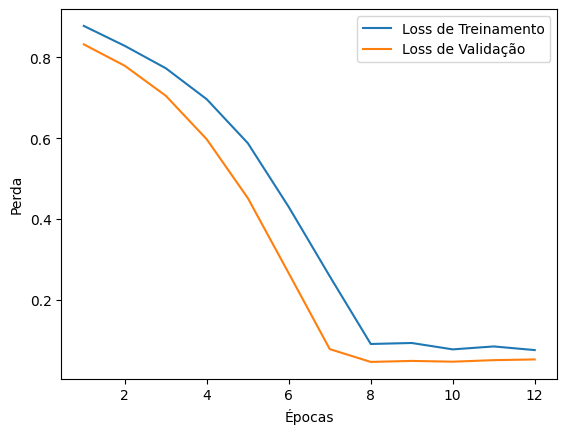

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 795ms/step - loss: 0.0864 - val_loss: 0.0425
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0821 - val_loss: 0.0423
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0801 - val_loss: 0.0376
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0757 - val_loss: 0.0428
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0794 - val_loss: 0.0368
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0748 - val_loss: 0.0380
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0827 - val_loss: 0.0361
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0804 - val_loss: 0.0406
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0822 - val_loss: 0.0403
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0766 - val_loss: 0.0367
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0780 - val_loss: 0.0416
Epoch 11: early 

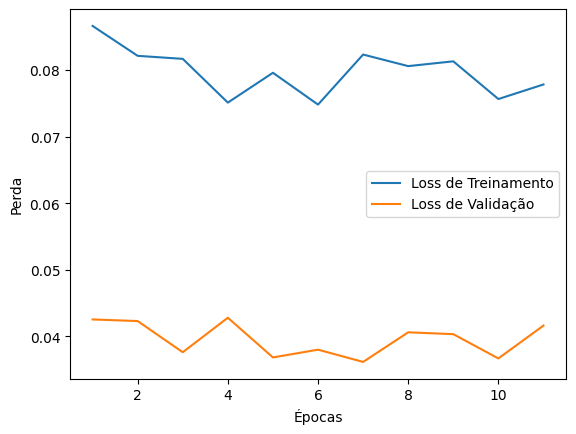

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step


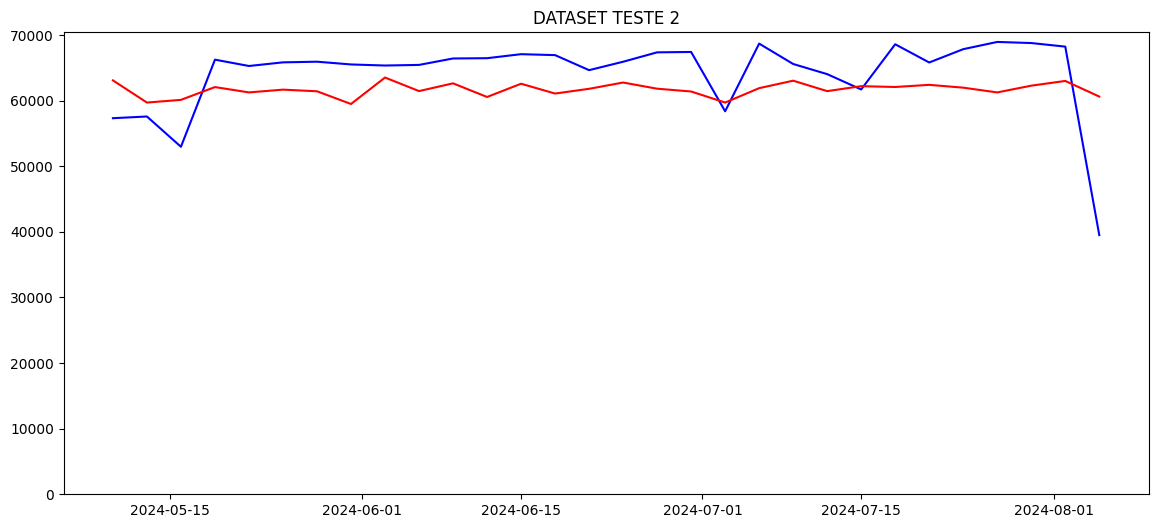

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_4.txt

Training with k-fold cross-validation, k=5


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.6700 - val_loss: 0.1196
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1748 - val_loss: 0.1929
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1675 - val_loss: 0.1601
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1718 - val_loss: 0.1670
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1665 - val_loss: 0.1226
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1740 - val_loss: 0.1201
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1642 - val_loss: 0.1733
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1687 - val_loss: 0.1169
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1575 - val_loss: 0.1543
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1567 - val_loss: 0.1118
Epoch 6/100000
14/14 ━━━━━━

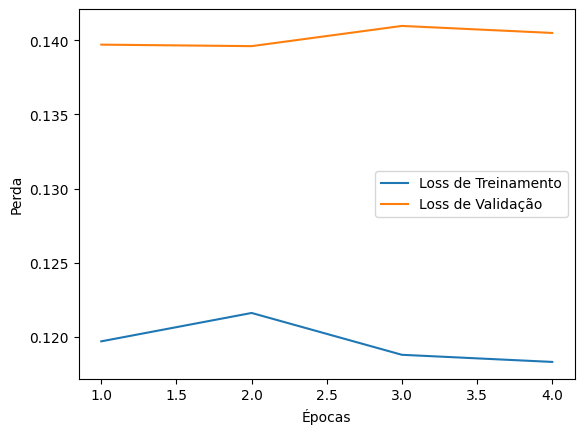

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.1420 - val_loss: 0.1185
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1277 - val_loss: 0.1202
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1272 - val_loss: 0.1182
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1270 - val_loss: 0.1179
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1279 - val_loss: 0.1394
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1289 - val_loss: 0.1260
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1271 - val_loss: 0.1284
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1285 - val_loss: 0.1266
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1252 - val_loss: 0.1246
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1346 - val_loss: 0.1208
Epoch 3/100000
14/14 ━━━━━━

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 870ms/step - loss: 0.8802 - val_loss: 0.8371
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8354 - val_loss: 0.7899
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.7859 - val_loss: 0.7269
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.7241 - val_loss: 0.6412
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.6365 - val_loss: 0.5299
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.5213 - val_loss: 0.3909
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.3877 - val_loss: 0.2312
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2203 - val_loss: 0.0874
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0964 - val_loss: 0.0480
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0819 - val_loss: 0.0419
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0716 - val_l

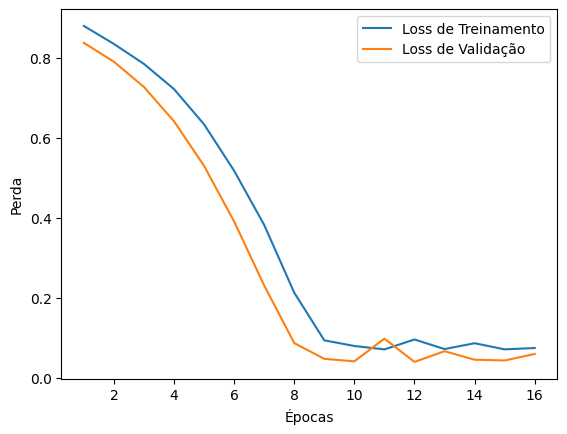

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - loss: 0.0697 - val_loss: 0.0364
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0830 - val_loss: 0.0378
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0899 - val_loss: 0.0409
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0748 - val_loss: 0.0347
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0651 - val_loss: 0.0348
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0725 - val_loss: 0.0334
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0688 - val_loss: 0.0394
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0687 - val_loss: 0.0360
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0684 - val_loss: 0.0340
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0753 - val_loss: 0.0405
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.


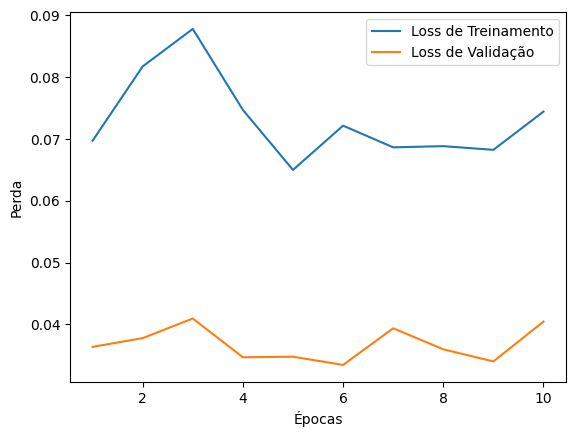

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


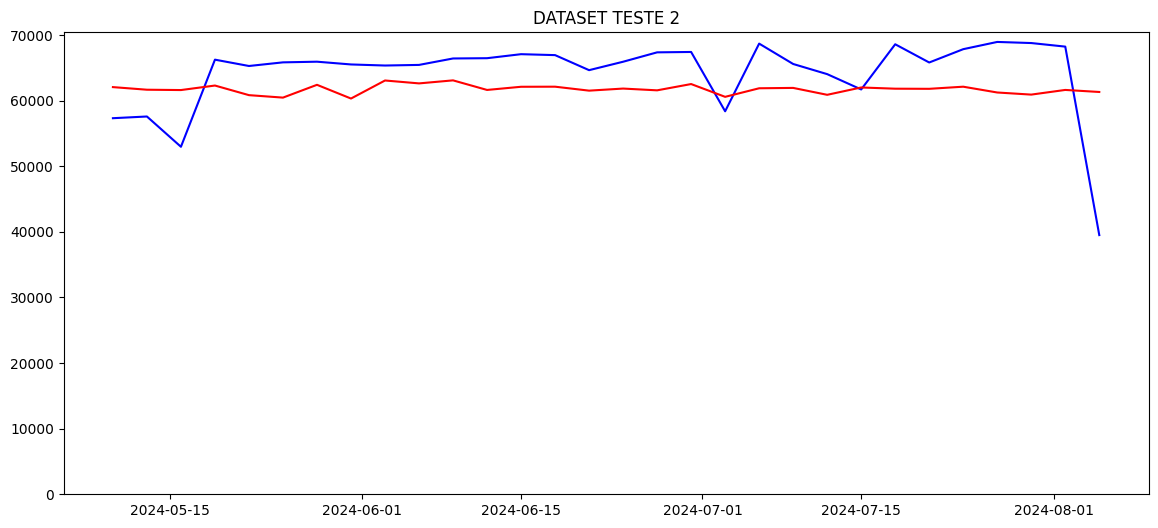

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_5.txt

Training with k-fold cross-validation, k=6


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.6527 - val_loss: 0.1101
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1831 - val_loss: 0.1761
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1685 - val_loss: 0.0985
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.1639 - val_loss: 0.1028
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1648 - val_loss: 0.1217
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1590 - val_loss: 0.1355
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1544 - val_loss: 0.1262
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1652 - val_loss: 0.1492
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1532 - val_loss: 0.1261
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1508 - val_loss: 0.1286
Epoch 4/100000
14/14 ━━━━━━

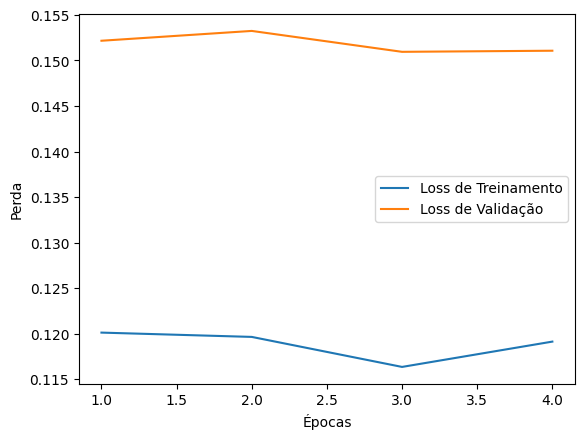

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - loss: 0.1347 - val_loss: 0.1178
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1209 - val_loss: 0.1263
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1242 - val_loss: 0.1197
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1259 - val_loss: 0.1266
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1246 - val_loss: 0.1228
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1253 - val_loss: 0.1161
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1280 - val_loss: 0.1160
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1239 - val_loss: 0.1178
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1233 - val_loss: 0.1190
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1238 - val_loss: 0.1215
Epoch 6/100000
14/14 ━━━━━

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 788ms/step - loss: 0.8797 - val_loss: 0.8347
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8331 - val_loss: 0.7870
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.7850 - val_loss: 0.7242
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7197 - val_loss: 0.6380
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6311 - val_loss: 0.5247
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5152 - val_loss: 0.3813
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3724 - val_loss: 0.2167
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.2171 - val_loss: 0.0659
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0928 - val_loss: 0.0508
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0738 - val_loss: 0.0428
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0829 - val_l

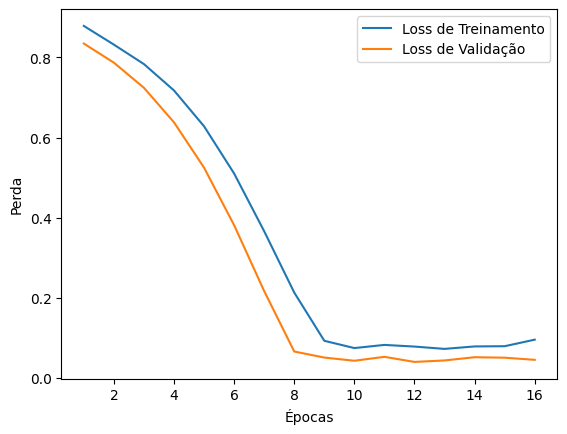

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 829ms/step - loss: 0.0747 - val_loss: 0.0380
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0682 - val_loss: 0.0482
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0690 - val_loss: 0.0470
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0726 - val_loss: 0.0335
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0728 - val_loss: 0.0362
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0654 - val_loss: 0.0335
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0749 - val_loss: 0.0475
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0720 - val_loss: 0.0418
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0707 - val_loss: 0.0357
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0683 - val_loss: 0.0350
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.


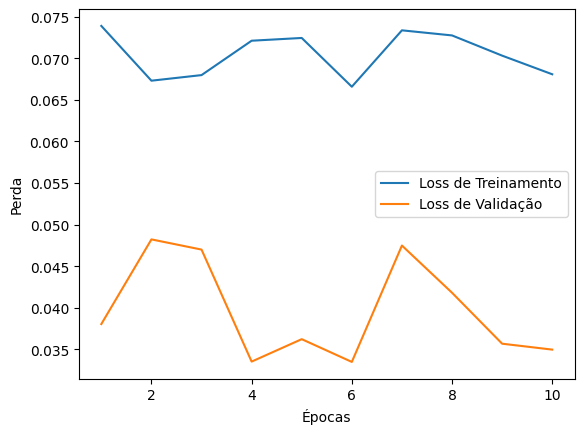

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step


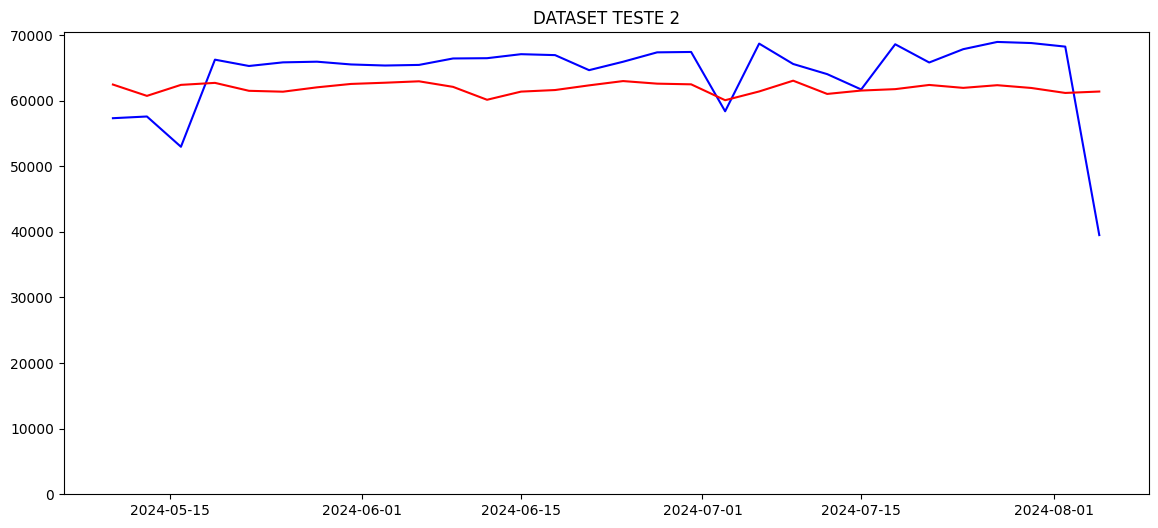

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_6.txt

Training with k-fold cross-validation, k=7


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 0.6619 - val_loss: 0.1175
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1691 - val_loss: 0.1398
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1619 - val_loss: 0.0924
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1589 - val_loss: 0.1259
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1591 - val_loss: 0.1438
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1538 - val_loss: 0.1466
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1495 - val_loss: 0.0900
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1507 - val_loss: 0.1148
Epoch 9/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1447 - val_loss: 0.1122
Epoch 10/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1443 - val_loss: 0.0950
Epoch 11/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1381 - val_loss: 0.1012
Epoch 11: early sto

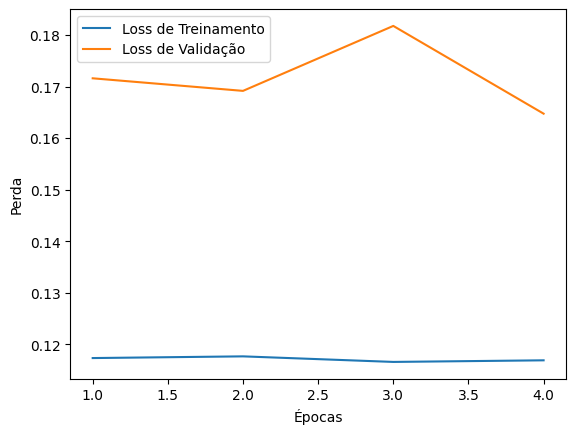

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.1303 - val_loss: 0.1260
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1246 - val_loss: 0.1313
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1272 - val_loss: 0.1210
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1258 - val_loss: 0.1201
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1269 - val_loss: 0.1228
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1266 - val_loss: 0.1215
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1267 - val_loss: 0.1184
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1267 - val_loss: 0.1169
Epoch 9/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1272 - val_loss: 0.1191
Epoch 10/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1240 - val_loss: 0.1182
Epoch 11/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1258 - val_loss: 0.1168
Epoch 12/100000
15/

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 893ms/step - loss: 0.8802 - val_loss: 0.8351
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.8329 - val_loss: 0.7868
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.7833 - val_loss: 0.7241
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.7215 - val_loss: 0.6383
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.6327 - val_loss: 0.5263
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.5216 - val_loss: 0.3837
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.3713 - val_loss: 0.2164
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.1924 - val_loss: 0.0714
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0950 - val_loss: 0.0642
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0809 - val_loss: 0.0594
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0754 - val

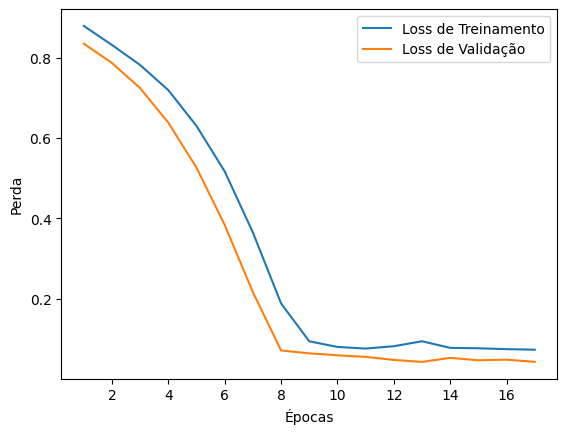

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 836ms/step - loss: 0.0756 - val_loss: 0.0618
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0838 - val_loss: 0.0504
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0810 - val_loss: 0.0362
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0873 - val_loss: 0.0370
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0759 - val_loss: 0.0350
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0814 - val_loss: 0.0365
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0711 - val_loss: 0.0360
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0737 - val_loss: 0.0440
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0777 - val_loss: 0.0386
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.


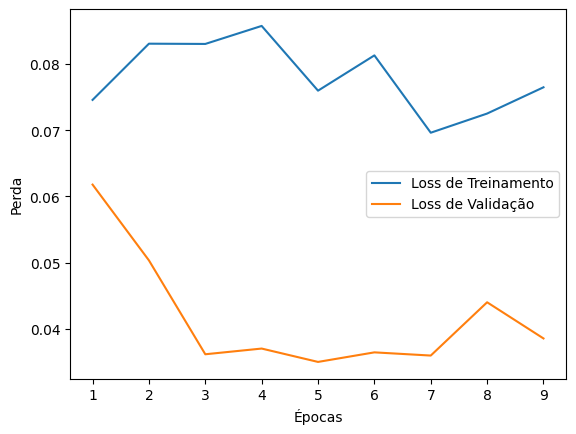

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


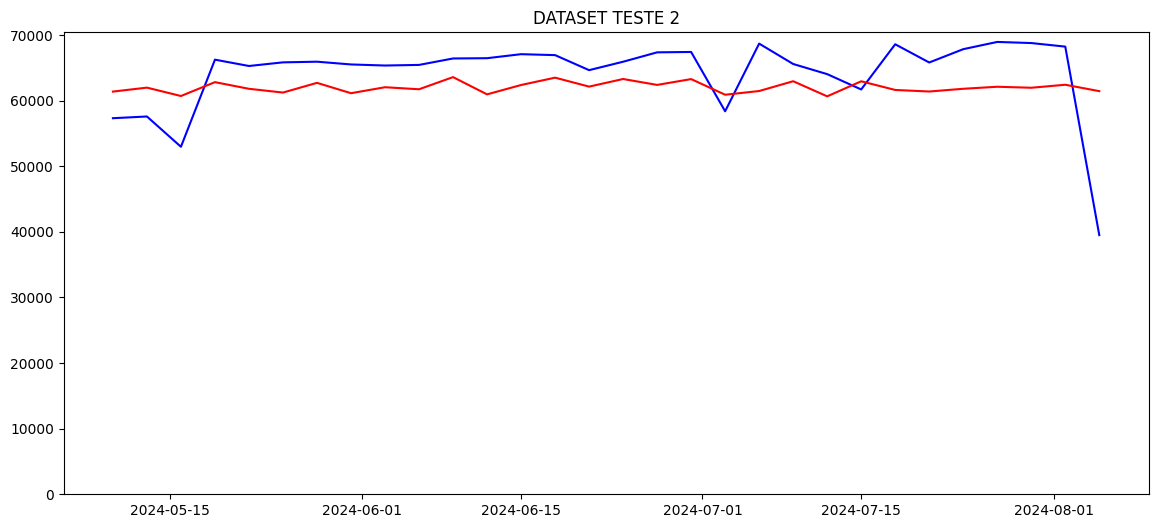

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_7.txt

Training with k-fold cross-validation, k=8


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.6524 - val_loss: 0.0853
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1649 - val_loss: 0.0879
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1634 - val_loss: 0.1019
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1522 - val_loss: 0.0814
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1523 - val_loss: 0.0877
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1452 - val_loss: 0.0907
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1421 - val_loss: 0.0884
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1448 - val_loss: 0.0936
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1485 - val_loss: 0.1538
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1469 - val_loss: 0.1719
Epoch 3/100000
15/15 ━━━━━━

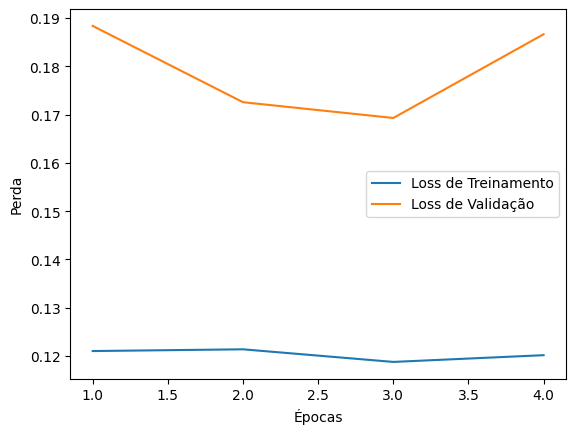

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.1381 - val_loss: 0.1170
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1316 - val_loss: 0.1163
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1266 - val_loss: 0.1122
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1240 - val_loss: 0.1116
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1262 - val_loss: 0.1093
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1297 - val_loss: 0.1110
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1282 - val_loss: 0.1077
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1271 - val_loss: 0.1193
Epoch 9/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1247 - val_loss: 0.1090
Epoch 10/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1248 - val_loss: 0.1080
Epoch 11/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1252 - val_loss: 0.1157
Epoch 11: early sto

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 779ms/step - loss: 0.8801 - val_loss: 0.8351
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8333 - val_loss: 0.7869
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.7843 - val_loss: 0.7238
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.7182 - val_loss: 0.6345
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.6309 - val_loss: 0.5186
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.5091 - val_loss: 0.3720
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.3536 - val_loss: 0.1985
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.2081 - val_loss: 0.0645
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0840 - val_loss: 0.0507
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0853 - val_loss: 0.0527
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0813 - val_l

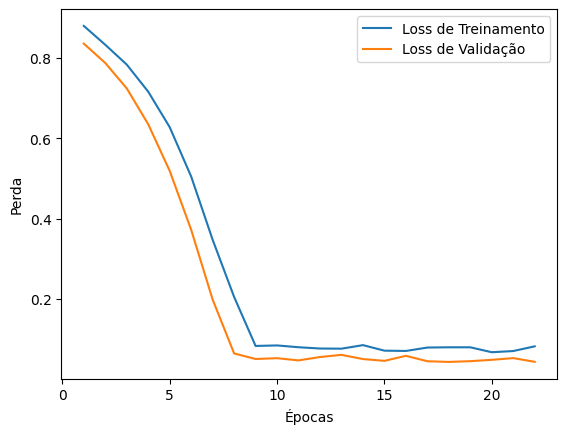

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 781ms/step - loss: 0.0714 - val_loss: 0.0426
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0722 - val_loss: 0.0384
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0851 - val_loss: 0.0396
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0760 - val_loss: 0.0413
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0761 - val_loss: 0.0432
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0733 - val_loss: 0.0429
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.


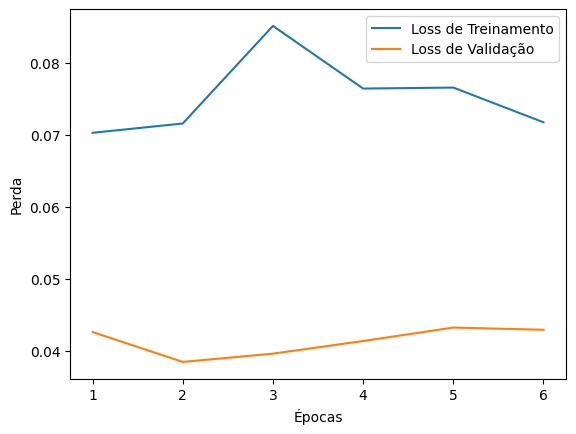

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step


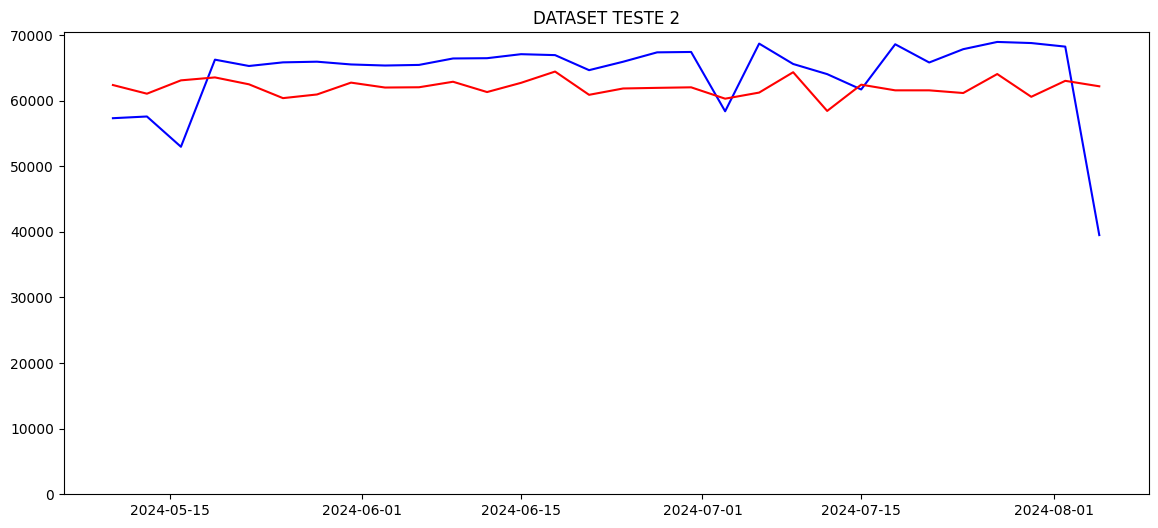

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_8.txt

Training with k-fold cross-validation, k=9


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - loss: 0.6585 - val_loss: 0.1101
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.1603 - val_loss: 0.0966
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1539 - val_loss: 0.0864
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1539 - val_loss: 0.1491
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1563 - val_loss: 0.0921
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1456 - val_loss: 0.0802
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1520 - val_loss: 0.0990
Epoch 8/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1460 - val_loss: 0.1097
Epoch 9/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1403 - val_loss: 0.0765
Epoch 10/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1419 - val_loss: 0.0868
Epoch 11/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1363 - val_loss: 0.0833
Epoch 12/100000
15

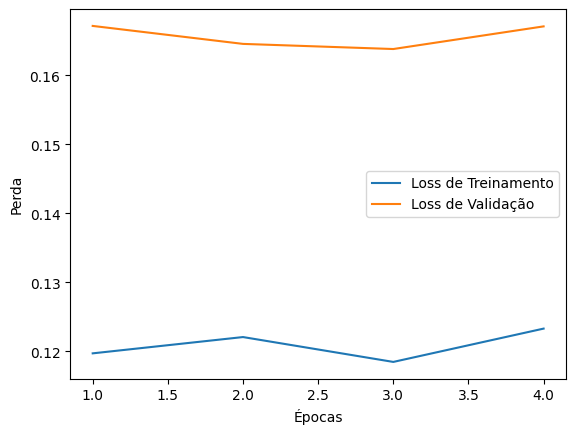

Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.1293 - val_loss: 0.1083
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1241 - val_loss: 0.1082
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1244 - val_loss: 0.1067
Epoch 4/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1250 - val_loss: 0.1074
Epoch 5/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1247 - val_loss: 0.1089
Epoch 6/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1254 - val_loss: 0.1082
Epoch 7/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1236 - val_loss: 0.1084
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1255 - val_loss: 0.1338
Epoch 2/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1202 - val_loss: 0.1337
Epoch 3/100000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1195 - val_loss: 0.1337
Epoch 4/100000
15/15 ━━━━━━

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 792ms/step - loss: 0.8803 - val_loss: 0.8384
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.8370 - val_loss: 0.7948
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.7922 - val_loss: 0.7381
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7389 - val_loss: 0.6622
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6551 - val_loss: 0.5581
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5473 - val_loss: 0.4248
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.4135 - val_loss: 0.2657
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2634 - val_loss: 0.1049
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1029 - val_loss: 0.0490
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0857 - val_loss: 0.0483
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0876 - val_l

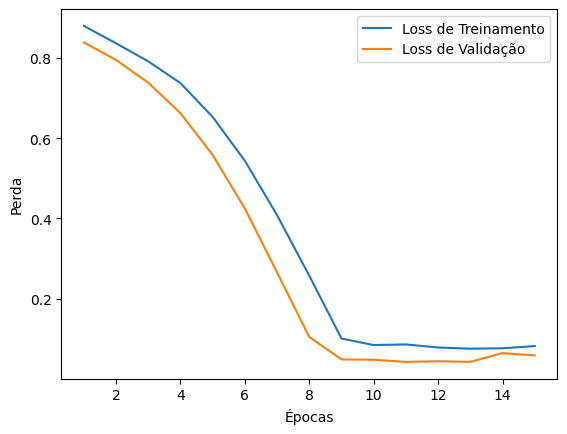

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 787ms/step - loss: 0.0736 - val_loss: 0.0425
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0786 - val_loss: 0.0401
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0695 - val_loss: 0.0366
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0756 - val_loss: 0.0359
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0676 - val_loss: 0.0347
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0720 - val_loss: 0.0347
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0751 - val_loss: 0.0472
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0748 - val_loss: 0.0413
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0742 - val_loss: 0.0438
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0744 - val_loss: 0.0457
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.


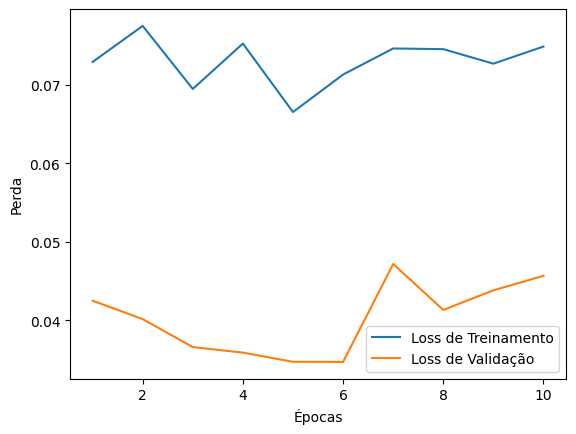

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step


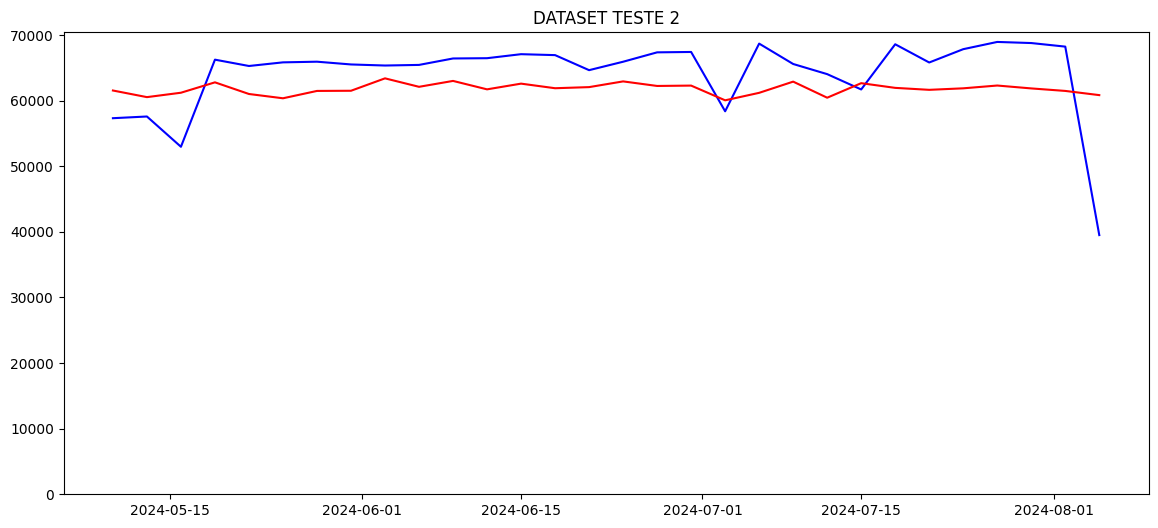

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_k-fold_9.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 809ms/step - loss: 0.8799 - val_loss: 0.8348
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.8330 - val_loss: 0.7852
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7815 - val_loss: 0.7184
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7098 - val_loss: 0.6258
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.6185 - val_loss: 0.5013
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.4924 - val_loss: 0.3484
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3426 - val_loss: 0.1798
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1761 - val_loss: 0.0547
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0766 - val_loss: 0.0402
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0849 - val_loss: 0.0451
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0770 - val_l

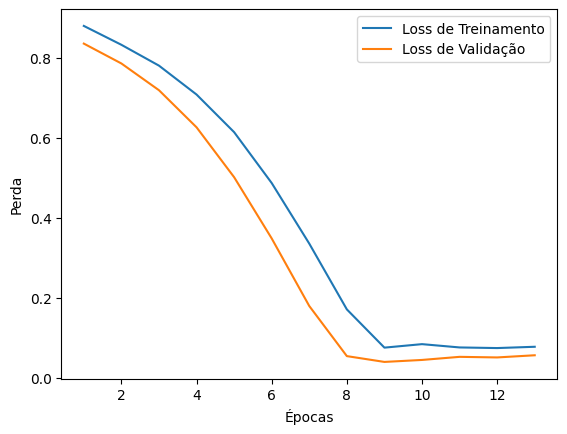

LSTM 1 treinable:  True
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 819ms/step - loss: 0.0709 - val_loss: 0.0580
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0892 - val_loss: 0.0360
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0647 - val_loss: 0.0346
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0676 - val_loss: 0.0406
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0721 - val_loss: 0.0371
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0745 - val_loss: 0.0540
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0738 - val_loss: 0.0366
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.


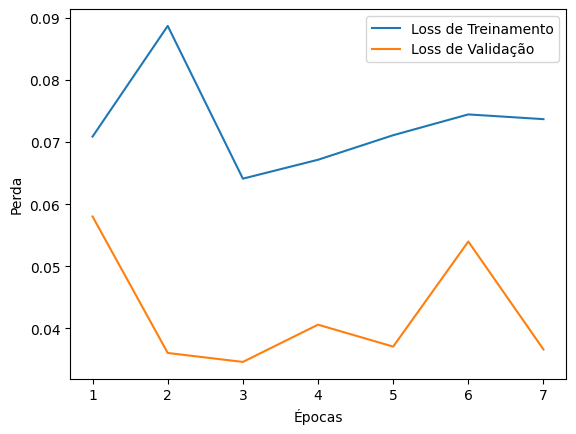

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


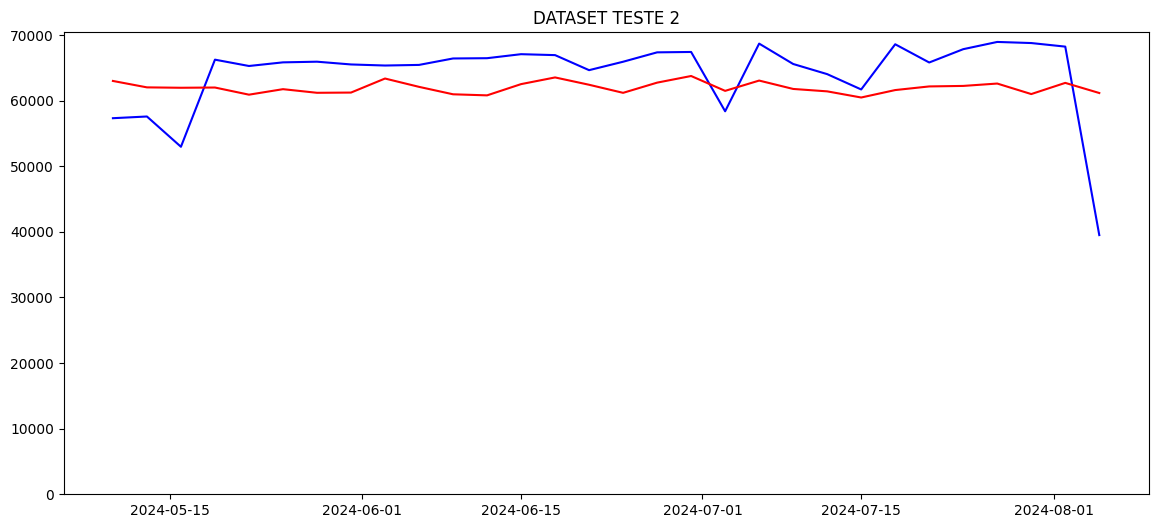

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_1\avaliacao_with_method_split.txt


In [27]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
for k in range(2, 10):
    validation_method = 'k-fold'
    print(f"\nTraining with k-fold cross-validation, k={k}")
    model1 = train_model(X_1, y_1, validation_method, k=k)
    transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, str(k))
    
# Treinamento com train-test split
print("\nTraining with train-test split")
validation_method = 'split'
model1 = train_model(X_1, y_1, validation_method, 3)
transfer_learning_model(config, model1, diretorio_pesos_teste_1, diretorio_avaliacao_teste_1, 'teste_1', validation_method, 'split')

In [28]:
# #model1 = create_model(config, dataset_type_du, X_1, y_1,validation_method, 4)
# for k in range(2,9):
#     model1 = create_model(config, dataset_type_du, X_1, y_1, 'k-fold', k)
#     results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, k)

# model1 = create_model(config, dataset_type_du, X_1, y_1, 'split', 0)
# results(model1, duas_unas_validation_scaled, validation_method, diretorio_avaliacao_teste_1, 'split')

In [29]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento1 = model1.get_weights()
# pesos_LSTM1_t1 = model1.layers[0].get_weights()
# pesos_LSTM2_t1 = model1.layers[2].get_weights()
# pesos_LSTM3_t1 = model1.layers[4].get_weights()
# pesos_DENSE_t1 = model1.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'), *pesos_LSTM1_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'), *pesos_LSTM2_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'), *pesos_LSTM3_t1)
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_DENSE_t1_{validation_method}.npz'), *pesos_DENSE_t1)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_1, f'pesos_modelo_t1_{validation_method}.npz'), *pesos_treinamento1)

# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz'))
# pesos_carregados_LSTM2_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz'))
# pesos_carregados_LSTM3_t1 = np.load(os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz'))

In [30]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model1_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model1_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model1_ft.add(Dropout(0.3))

# model1_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model1_ft.summary()

In [31]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM1_t1_{validation_method}.npz')
# caminho_LSTM2_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM2_t1_{validation_method}.npz')
# caminho_LSTM3_t1 = os.path.join(diretorio_pesos_teste_1, f'pesos_LSTM3_t1_{validation_method}.npz')

# carregar_e_aplicar_pesos(model1_ft, caminho_LSTM1_t1, caminho_LSTM2_t1, caminho_LSTM3_t1)

In [32]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t1[0], model1_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t1[1], model1_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t1[2], model1_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t1[0], model1_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t1[1], model1_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t1[2], model1_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t1[0], model1_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t1[1], model1_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t1[2], model1_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)


In [33]:
# congelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# descongelar_camadas(model1_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model1_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model1_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [35]:
# pred = model1_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 1")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_1, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [36]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_1)

## **TESTE 02**

Prata I, II, III e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 02 ###

indices = [1, 2, 3, 4]
dataset_test_2 = concatenate_selected_datasets(scaled_datasets, indices)

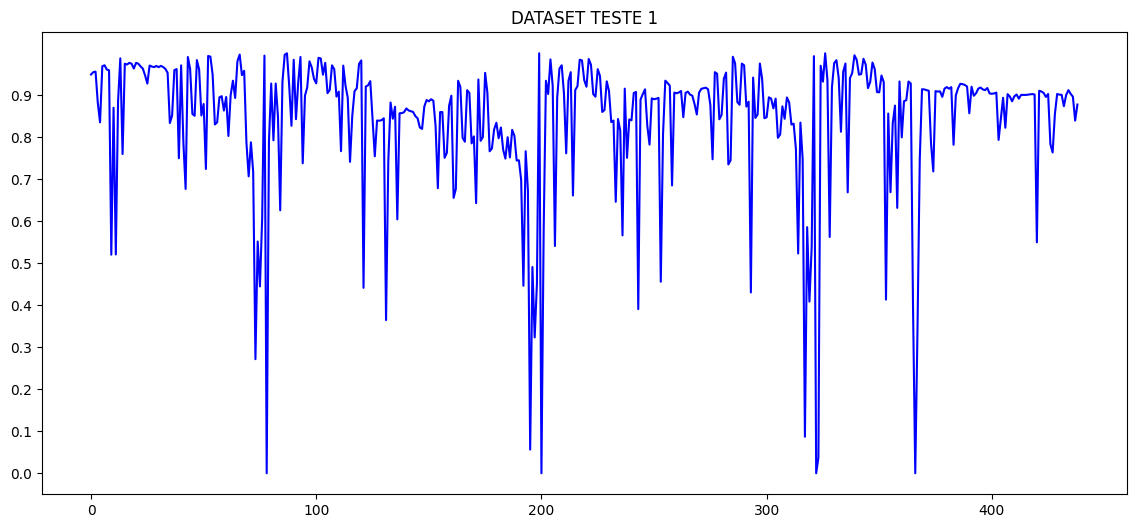

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_2, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_2, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

X shape (409, 1)
y shape (409, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - loss: 0.7494 - val_loss: 0.1741
Epoch 2/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1694 - val_loss: 0.1508
Epoch 3/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1630 - val_loss: 0.1331
Epoch 4/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1542 - val_loss: 0.1582
Epoch 5/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1597 - val_loss: 0.1268
Epoch 6/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1440 - val_loss: 0.2132
Epoch 7/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1653 - val_loss: 0.1536
Epoch 8/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1504 - val_loss: 0.1255
Epoch 9/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1423 - val_loss: 0.1403
Epoch 10/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1401 - val_loss: 0.1393
Epoch 11/100000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1382 - val_loss: 0.1677
Epoch 12/100000
11

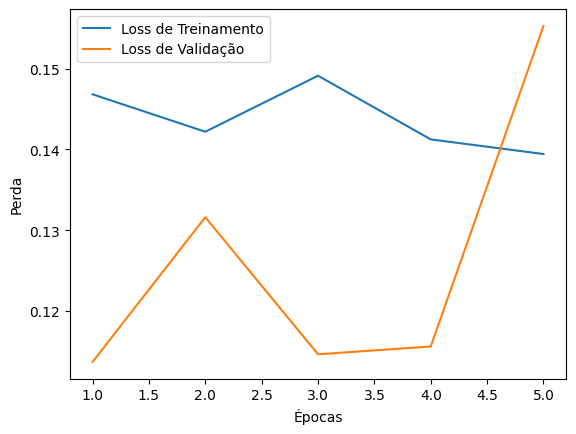

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step


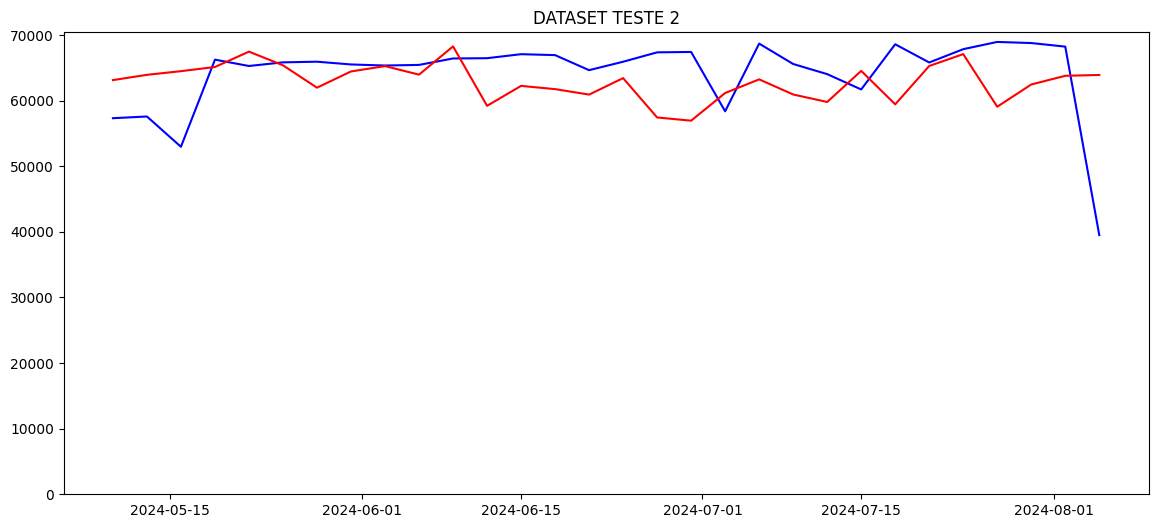

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 0.6863 - val_loss: 0.1350
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1702 - val_loss: 0.1132
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1561 - val_loss: 0.1167
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1563 - val_loss: 0.1118
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1563 - val_loss: 0.1614
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1490 - val_loss: 0.1096
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1536 - val_loss: 0.1085
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1433 - val_loss: 0.1087
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1451 - val_loss: 0.1139
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1301 - val_loss: 0.1064
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1406 - val_loss: 0.1113
Epoch 12/100000
14/

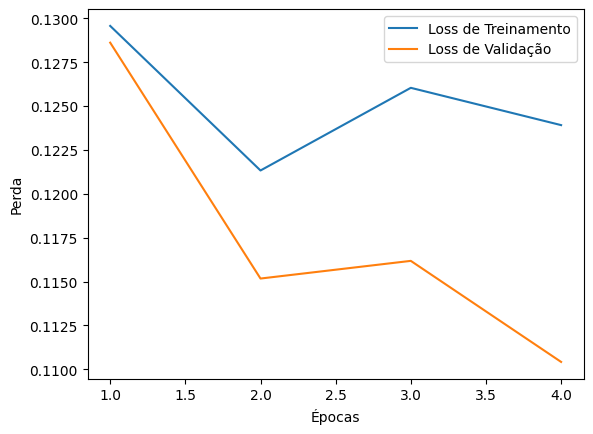

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


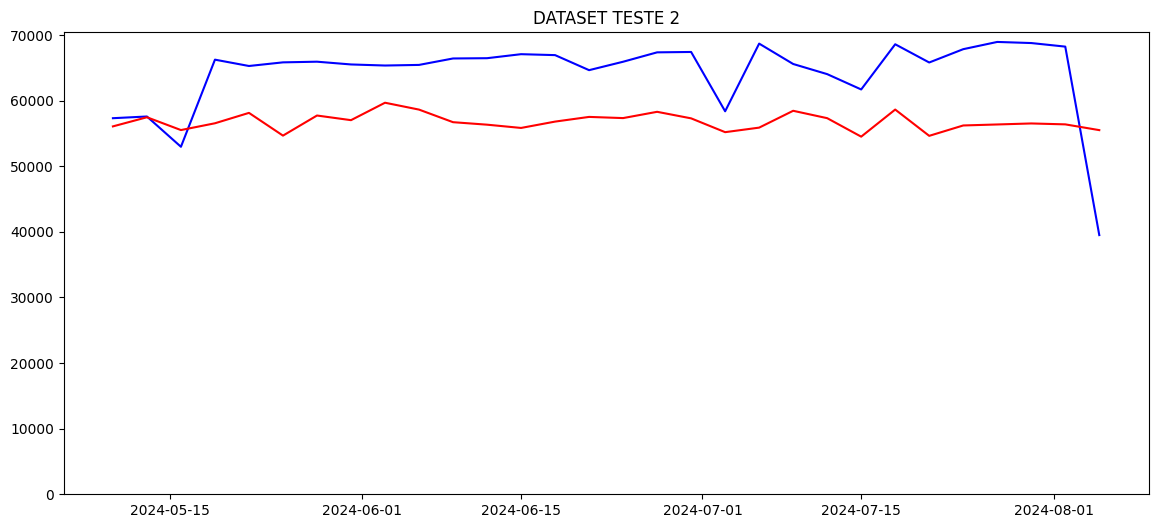

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_3.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - loss: 0.6540 - val_loss: 0.1314
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1606 - val_loss: 0.1545
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1555 - val_loss: 0.1540
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1498 - val_loss: 0.1269
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1505 - val_loss: 0.1181
Epoch 6/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1420 - val_loss: 0.1117
Epoch 7/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1464 - val_loss: 0.1108
Epoch 8/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1380 - val_loss: 0.1096
Epoch 9/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1361 - val_loss: 0.1161
Epoch 10/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1324 - val_loss: 0.1347
Epoch 11/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1311 - val_loss: 0.1089
Epoch 12/100000
16/

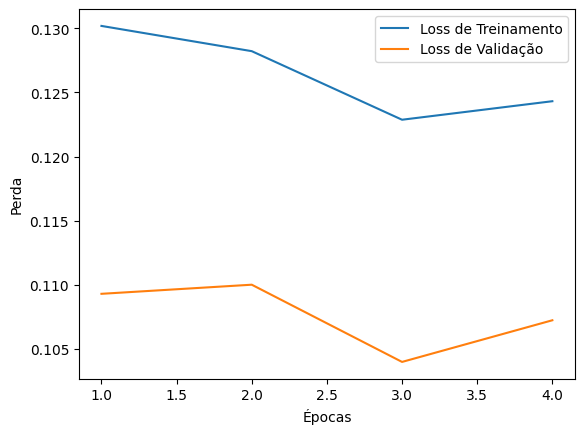

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


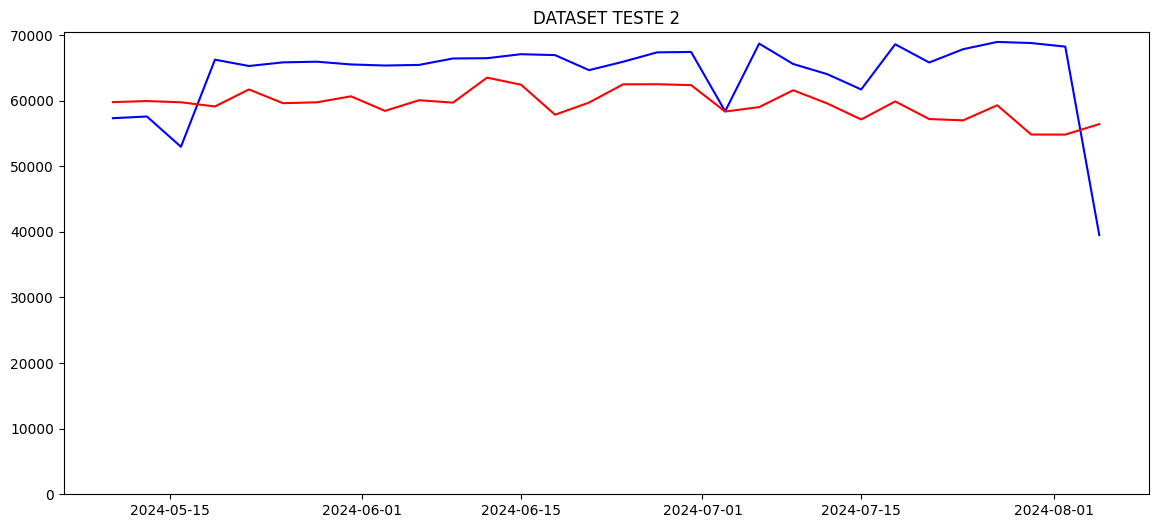

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 0.6285 - val_loss: 0.1533
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1667 - val_loss: 0.1266
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1570 - val_loss: 0.1216
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1476 - val_loss: 0.1289
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1443 - val_loss: 0.1233
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1422 - val_loss: 0.1196
Epoch 7/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1445 - val_loss: 0.1172
Epoch 8/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1335 - val_loss: 0.1158
Epoch 9/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1336 - val_loss: 0.1159
Epoch 10/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1331 - val_loss: 0.1165
Epoch 11/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1281 - val_loss: 0.1156
Epoch 12/100000
17/

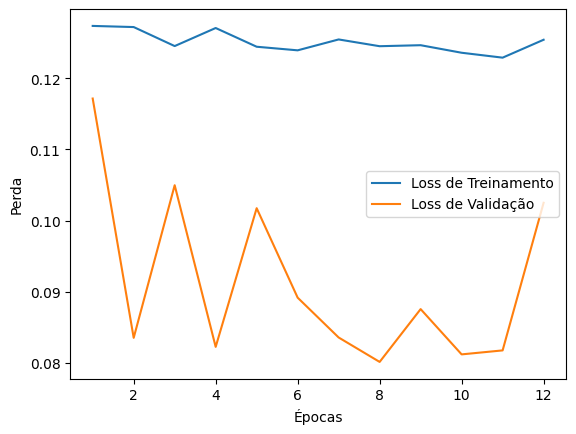

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


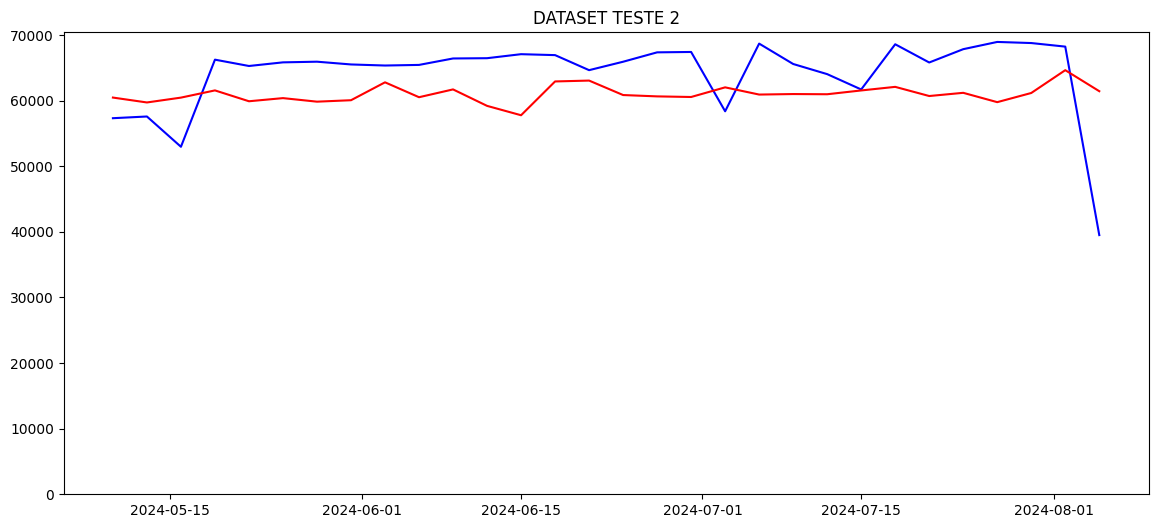

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.6320 - val_loss: 0.1531
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1607 - val_loss: 0.1184
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1527 - val_loss: 0.1639
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1517 - val_loss: 0.1349
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1439 - val_loss: 0.1249
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1430 - val_loss: 0.1159
Epoch 7/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1409 - val_loss: 0.1191
Epoch 8/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1359 - val_loss: 0.1267
Epoch 9/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1338 - val_loss: 0.1106
Epoch 10/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1312 - val_loss: 0.1172
Epoch 11/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1285 - val_loss: 0.1190
Epoch 12/100000
17/

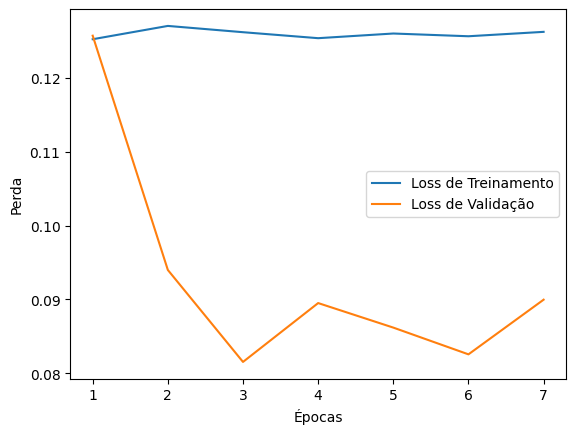

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step


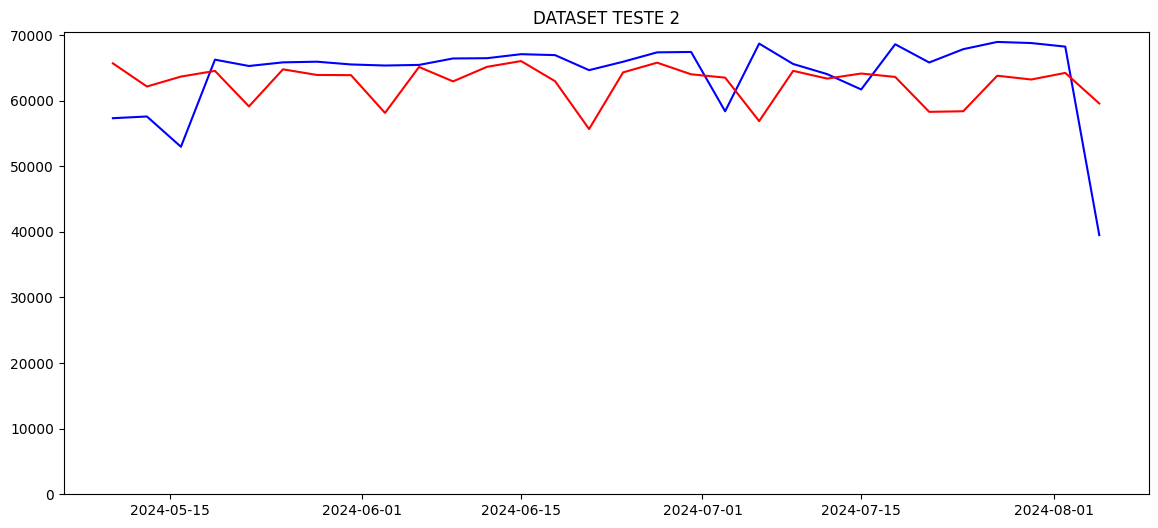

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.6084 - val_loss: 0.1176
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1645 - val_loss: 0.1326
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1702 - val_loss: 0.1099
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1553 - val_loss: 0.1027
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1529 - val_loss: 0.1890
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1526 - val_loss: 0.1900
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1511 - val_loss: 0.1015
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1396 - val_loss: 0.1513
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1456 - val_loss: 0.1025
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1328 - val_loss: 0.1023
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1320 - val_loss: 0.1010
Epoch 12/100000
18/

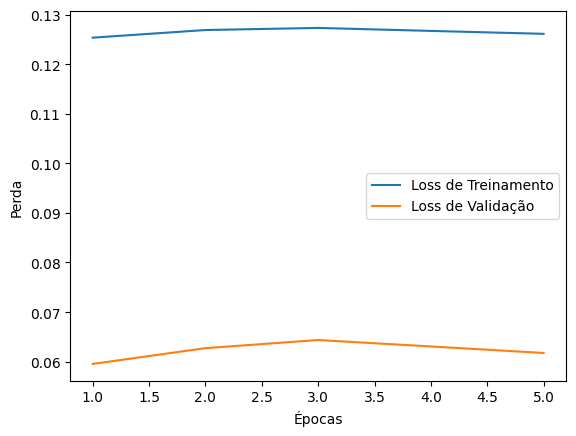

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


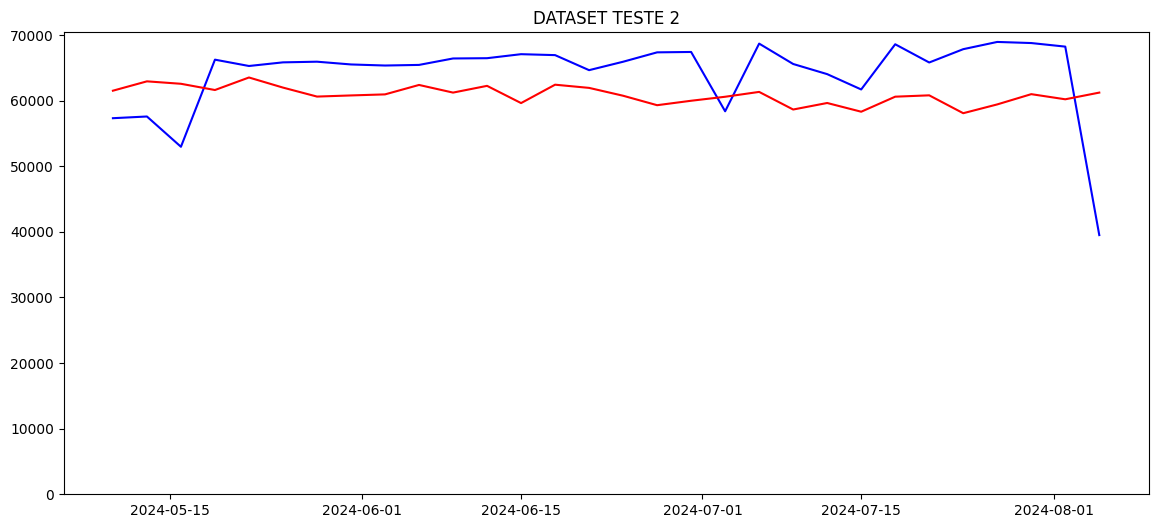

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.6174 - val_loss: 0.1022
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1667 - val_loss: 0.0978
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1676 - val_loss: 0.0929
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1538 - val_loss: 0.0903
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1521 - val_loss: 0.0902
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1417 - val_loss: 0.1059
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1440 - val_loss: 0.0998
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1367 - val_loss: 0.0880
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1348 - val_loss: 0.1172
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1363 - val_loss: 0.0921
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1305 - val_loss: 0.0893
Epoch 12/100000
18/

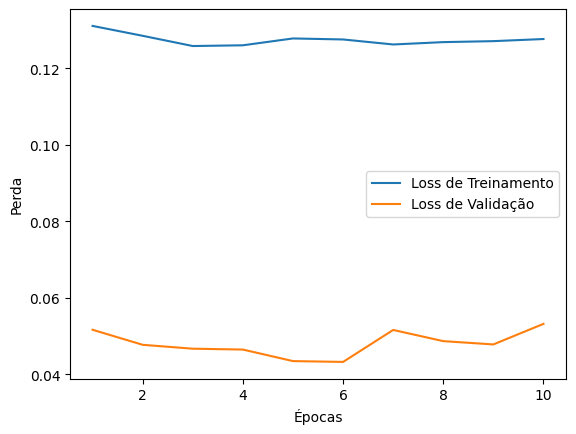

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


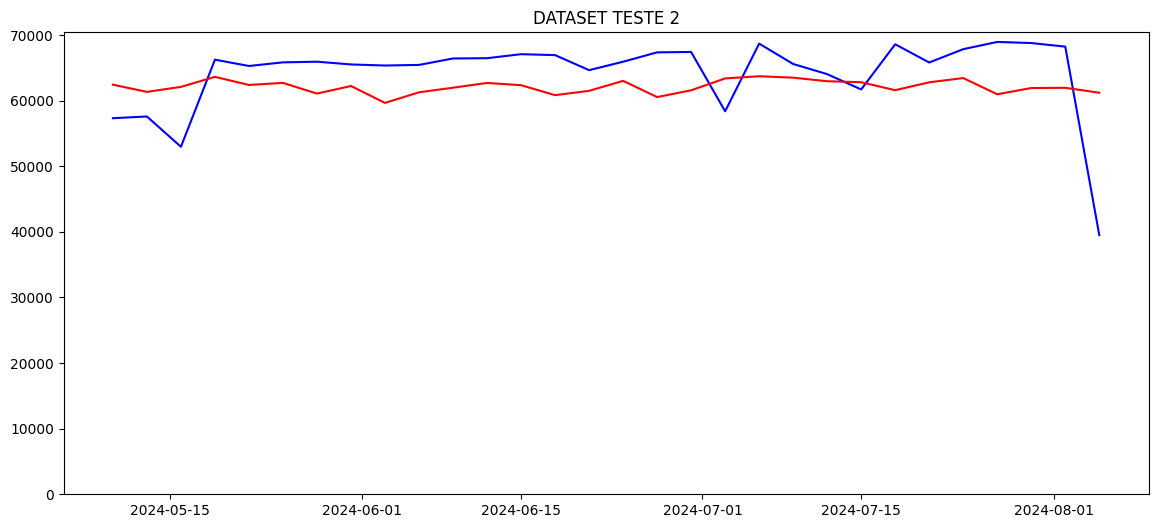

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_k-fold_8.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - loss: 0.6398 - val_loss: 0.1250
Epoch 2/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1593 - val_loss: 0.1328
Epoch 3/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1491 - val_loss: 0.1177
Epoch 4/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1517 - val_loss: 0.1285
Epoch 5/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1450 - val_loss: 0.1132
Epoch 6/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1472 - val_loss: 0.1100
Epoch 7/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1396 - val_loss: 0.1295
Epoch 8/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1361 - val_loss: 0.1134
Epoch 9/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1359 - val_loss: 0.1123
Epoch 10/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1372 - val_loss: 0.1100
Epoch 11/100000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1346 - val_loss: 0.1108
Epoch 12/100000
17/

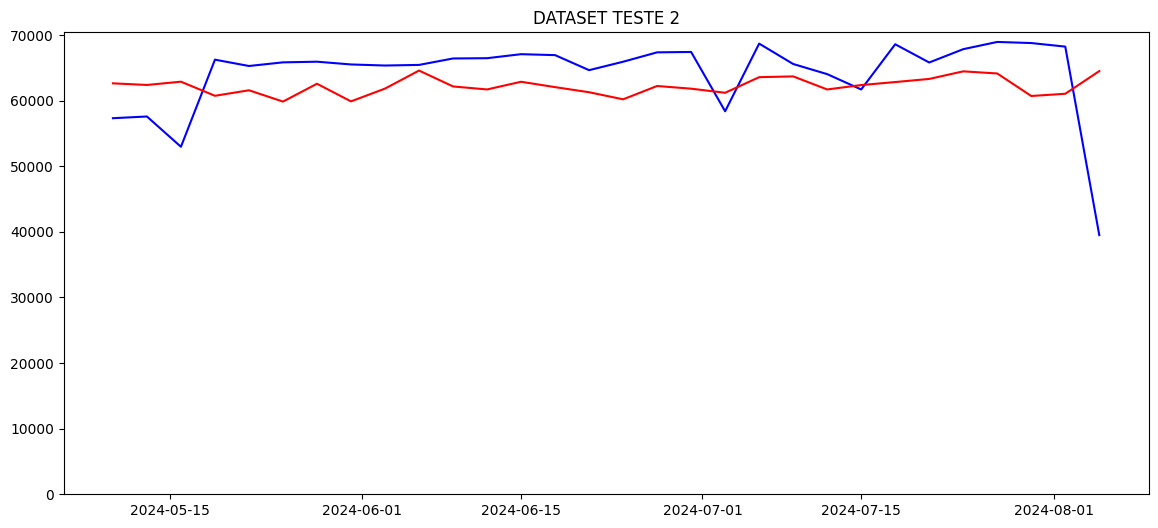

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_2\avaliacao_with_method_split.txt


In [27]:
for k in range(2,9):
    model_2 = create_model(config, dataset_type_du, X, y, 'k-fold', k)
    results(model_2, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_2, k)

model_2 = create_model(config, dataset_type_du, X, y, 'split', 0)
results(model_2, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_2, 'split')

## **TESTE 03**

Prata I, II, III, Pirapama e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Pirapama);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 03 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [0, 1, 2, 3]
dataset_test_3 = concatenate_selected_datasets(scaled_datasets, indices)

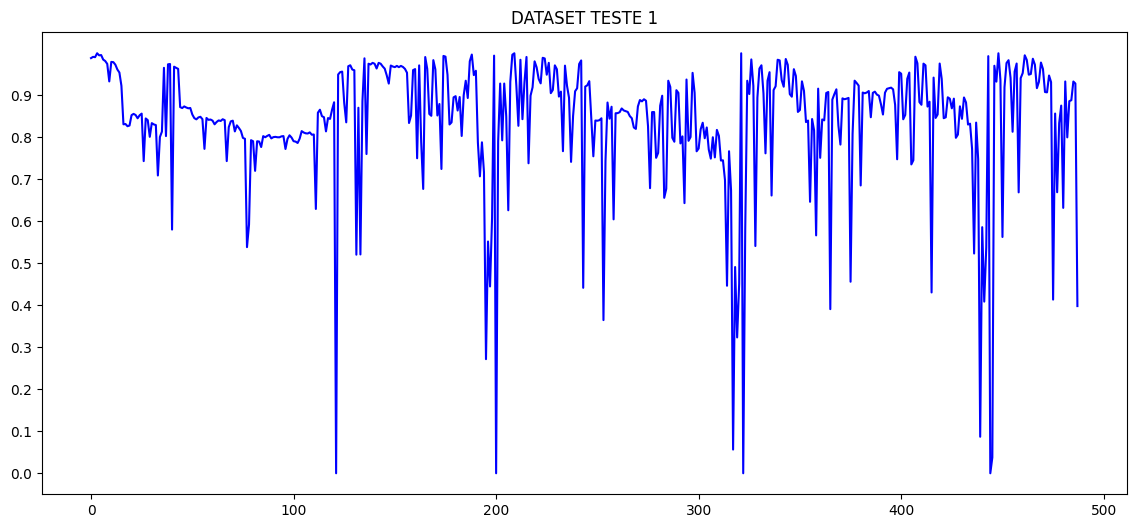

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_3, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_3, y_3 = create_dataset(dataset_test_3, timesteps, output_steps)
X_3 = X_3.reshape(X_3.shape[0], X_3.shape[1], 1)

#model3 = create_model(config, dataset_type_du, X_3, y_3, validation_method, 3)

X shape (458, 1)
y shape (458, 30)



Training with k-fold cross-validation, k=2


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - loss: 0.7116 - val_loss: 0.1362
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1810 - val_loss: 0.1224
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1655 - val_loss: 0.1123
Epoch 4/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1529 - val_loss: 0.1324
Epoch 5/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1651 - val_loss: 0.1018
Epoch 6/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1455 - val_loss: 0.1004
Epoch 7/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1443 - val_loss: 0.1007
Epoch 8/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1439 - val_loss: 0.1374
Epoch 9/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1436 - val_loss: 0.1008
Epoch 10/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1468 - val_loss: 0.0956
Epoch 11/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1406 - val_loss: 0.0956
Epoch 12/100000
12

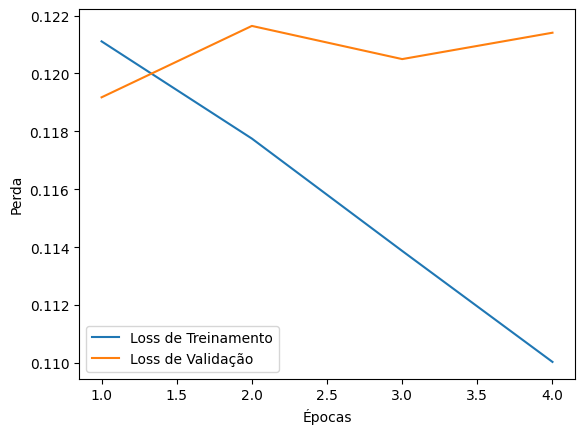

Epoch 1/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - loss: 0.1413 - val_loss: 0.1143
Epoch 2/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1276 - val_loss: 0.1069
Epoch 3/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1189 - val_loss: 0.1179
Epoch 4/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1332 - val_loss: 0.1057
Epoch 5/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1217 - val_loss: 0.1050
Epoch 6/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1192 - val_loss: 0.1070
Epoch 7/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1184 - val_loss: 0.1049
Epoch 8/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1167 - val_loss: 0.1238
Epoch 9/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1232 - val_loss: 0.1047
Epoch 10/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1167 - val_loss: 0.1060
Epoch 11/100000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1173 - val_loss: 0.1056
Epoch 12/100000
12/

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.8798 - val_loss: 0.8391
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.8371 - val_loss: 0.7914
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - loss: 0.7879 - val_loss: 0.7267
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.7225 - val_loss: 0.6347
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.6286 - val_loss: 0.5100
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.5082 - val_loss: 0.3532
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.3369 - val_loss: 0.1673
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1529 - val_loss: 0.0568
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0842 - val_loss: 0.0479
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0757 - val_loss: 0.0829
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1066 - val_lo

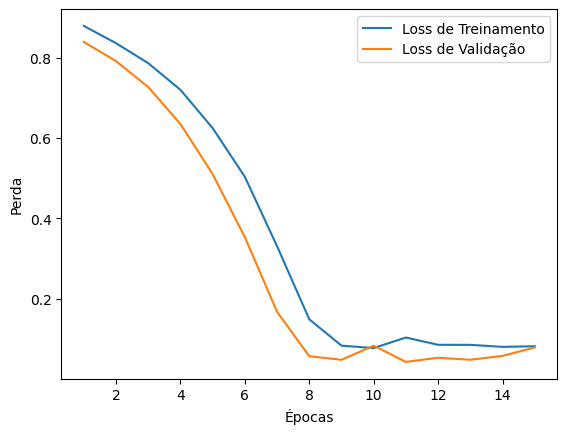

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step


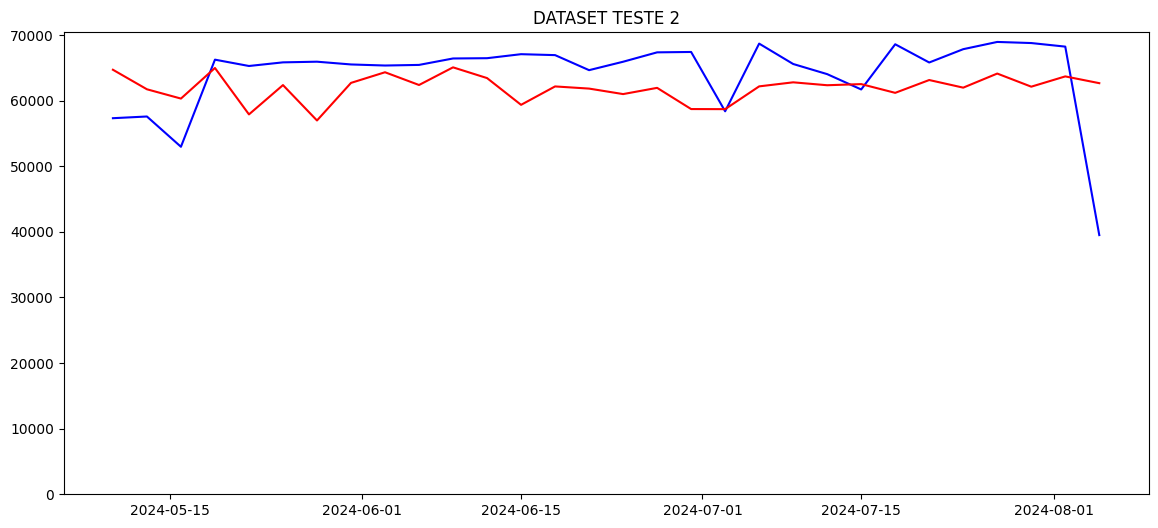

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_2.txt

Training with k-fold cross-validation, k=3


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.6538 - val_loss: 0.0913
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1700 - val_loss: 0.0871
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1596 - val_loss: 0.1151
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1564 - val_loss: 0.0865
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1502 - val_loss: 0.0829
Epoch 6/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1528 - val_loss: 0.1023
Epoch 7/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1439 - val_loss: 0.0835
Epoch 8/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1414 - val_loss: 0.0846
Epoch 9/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1351 - val_loss: 0.1026
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1450 - val_loss: 0.1324
Epoch 2/100000
16/16 ━━━━━

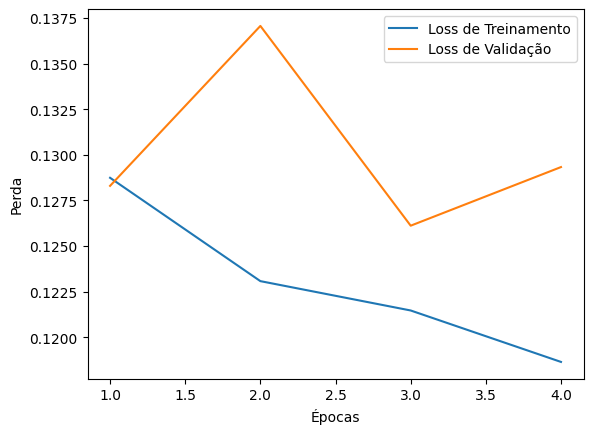

Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - loss: 0.1411 - val_loss: 0.1128
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1282 - val_loss: 0.1207
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1197 - val_loss: 0.1141
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1244 - val_loss: 0.1167
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1238 - val_loss: 0.1194
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1293 - val_loss: 0.1071
Epoch 2/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1274 - val_loss: 0.1072
Epoch 3/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1246 - val_loss: 0.1332
Epoch 4/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1308 - val_loss: 0.1063
Epoch 5/100000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1205 - val_loss: 0.1134
Epoch 6/100000
16/16 ━━━━━━

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 826ms/step - loss: 0.8787 - val_loss: 0.8333
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.8308 - val_loss: 0.7795
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.7740 - val_loss: 0.6982
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.6890 - val_loss: 0.5777
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5658 - val_loss: 0.4113
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.3952 - val_loss: 0.2045
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1879 - val_loss: 0.0774
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1149 - val_loss: 0.0514
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0831 - val_loss: 0.0503
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0787 - val_loss: 0.0548
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0884 - val_l

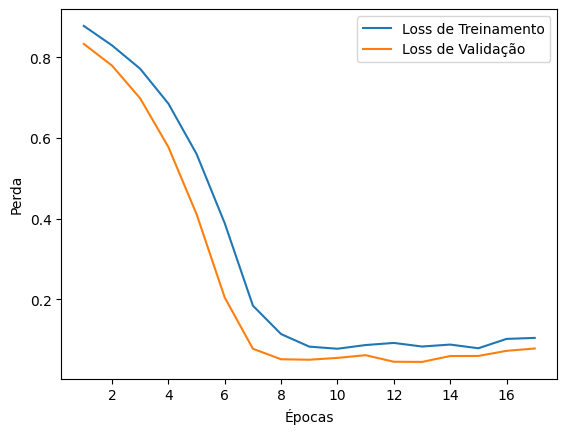

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


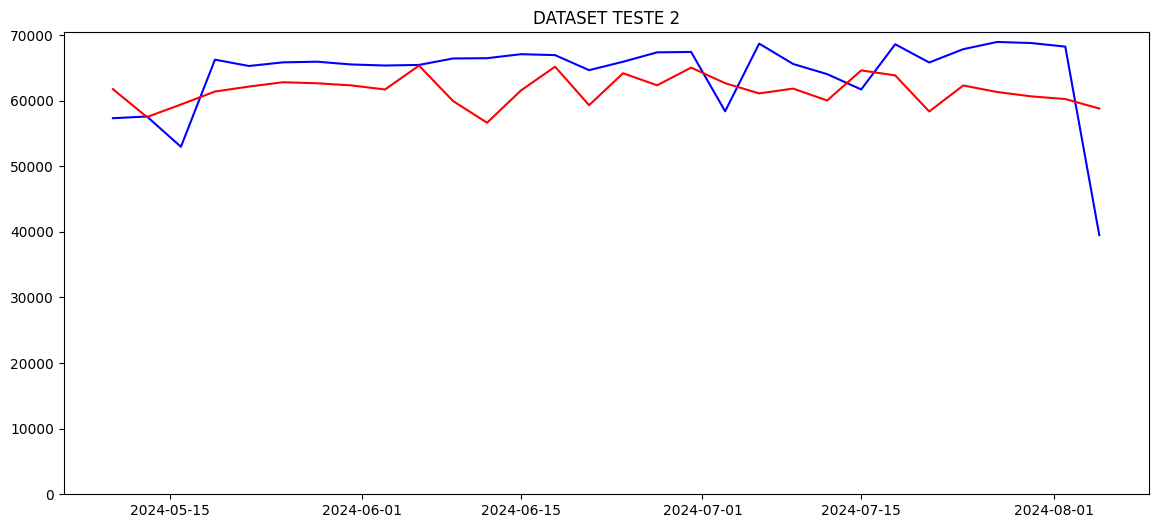

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_3.txt

Training with k-fold cross-validation, k=4


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.6221 - val_loss: 0.0874
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1649 - val_loss: 0.0969
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1680 - val_loss: 0.1086
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1616 - val_loss: 0.0836
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1546 - val_loss: 0.0745
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1497 - val_loss: 0.1014
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1472 - val_loss: 0.0723
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1497 - val_loss: 0.1204
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1436 - val_loss: 0.0731
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1433 - val_loss: 0.0720
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1402 - val_loss: 0.0757
Epoch 12/100000
18/

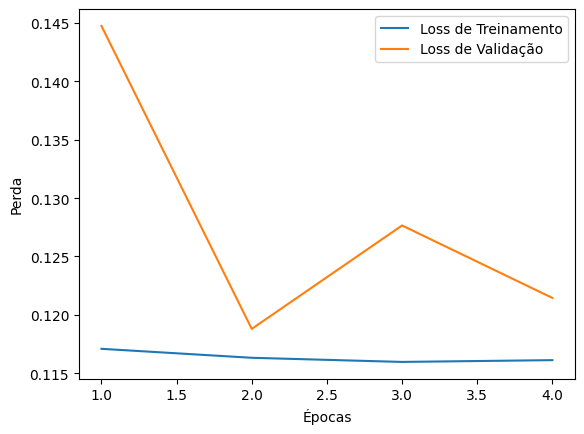

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - loss: 0.1254 - val_loss: 0.1157
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1207 - val_loss: 0.1245
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1203 - val_loss: 0.1210
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1170 - val_loss: 0.1062
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1186 - val_loss: 0.1156
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1198 - val_loss: 0.1088
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1174 - val_loss: 0.1110
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1199 - val_loss: 0.1219
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1166 - val_loss: 0.1212
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1189 - val_loss: 0.1240
Epoch 3/100000
18/18 ━━━━━

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 801ms/step - loss: 0.8799 - val_loss: 0.8344
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8318 - val_loss: 0.7844
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.7796 - val_loss: 0.7163
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7122 - val_loss: 0.6217
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.6167 - val_loss: 0.4964
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.4808 - val_loss: 0.3358
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3435 - val_loss: 0.1626
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1567 - val_loss: 0.0593
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0954 - val_loss: 0.0444
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0884 - val_loss: 0.0430
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0860 - val_l

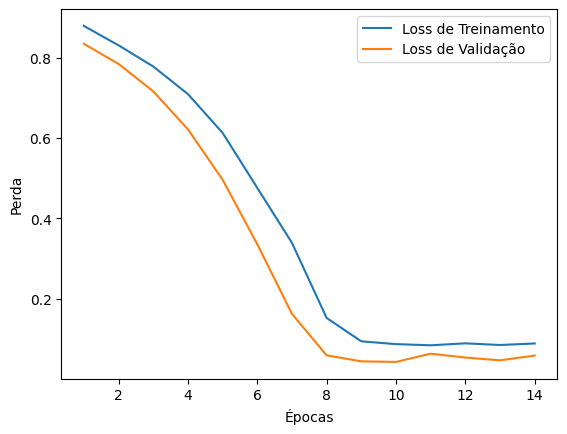

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step


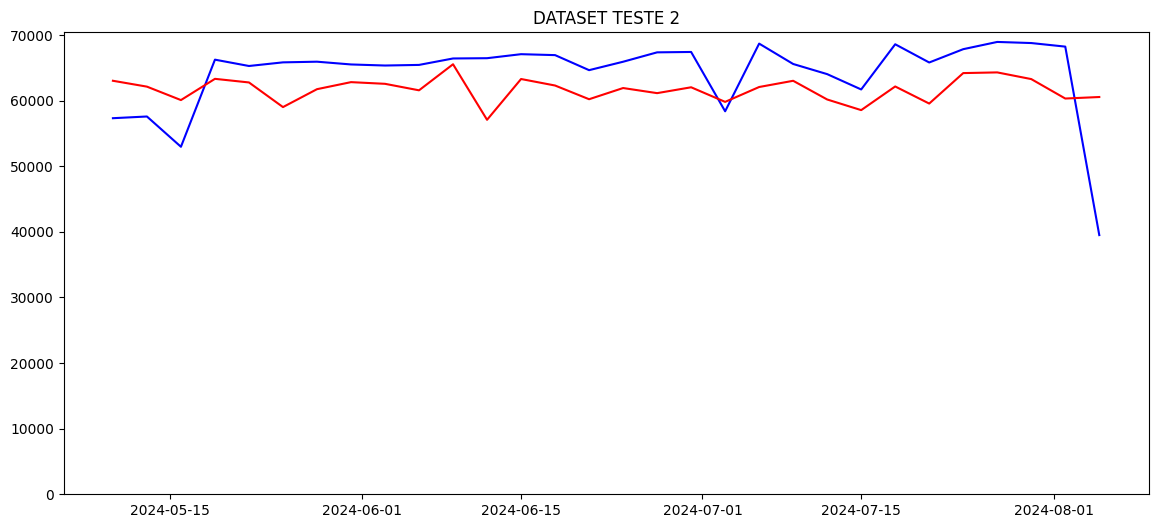

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_4.txt

Training with k-fold cross-validation, k=5


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.6112 - val_loss: 0.0723
Epoch 2/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1648 - val_loss: 0.1756
Epoch 3/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1648 - val_loss: 0.1690
Epoch 4/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1676 - val_loss: 0.1231
Epoch 5/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1587 - val_loss: 0.1500
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1585 - val_loss: 0.2027
Epoch 2/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1521 - val_loss: 0.1408
Epoch 3/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1428 - val_loss: 0.1843
Epoch 4/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1473 - val_loss: 0.1346
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Epoch 1/100000
19/19 ━━━━━━━━━━━━

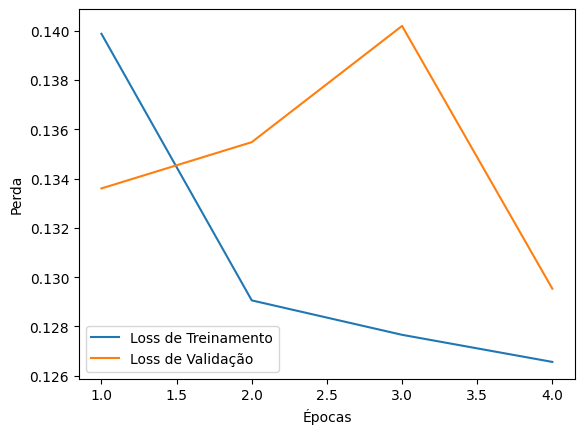

Epoch 1/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - loss: 0.1454 - val_loss: 0.1702
Epoch 2/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1373 - val_loss: 0.1077
Epoch 3/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1261 - val_loss: 0.1784
Epoch 4/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1383 - val_loss: 0.1324
Epoch 5/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1264 - val_loss: 0.1611
Epoch 6/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1296 - val_loss: 0.1052
Epoch 7/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1195 - val_loss: 0.1184
Epoch 8/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1184 - val_loss: 0.1204
Epoch 9/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1208 - val_loss: 0.1354
Epoch 10/100000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1253 - val_loss: 0.1153
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 6.
Epoch 1/100000
19/19 ━━

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 902ms/step - loss: 0.8800 - val_loss: 0.8352
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.8326 - val_loss: 0.7829
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.7782 - val_loss: 0.7100
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.7061 - val_loss: 0.6059
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.5990 - val_loss: 0.4647
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.4550 - val_loss: 0.2858
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2828 - val_loss: 0.1045
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1168 - val_loss: 0.0693
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0862 - val_loss: 0.0474
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0815 - val_loss: 0.0437
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0787 - va

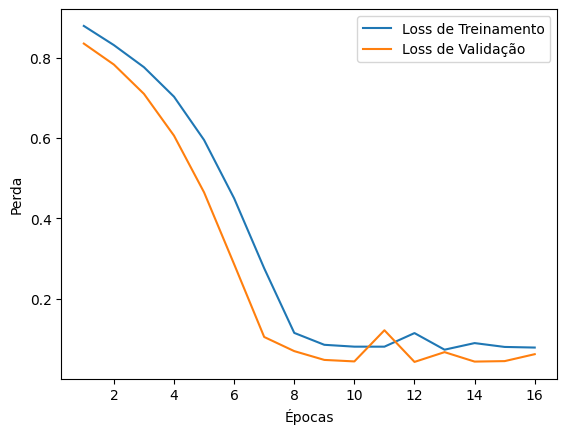

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step


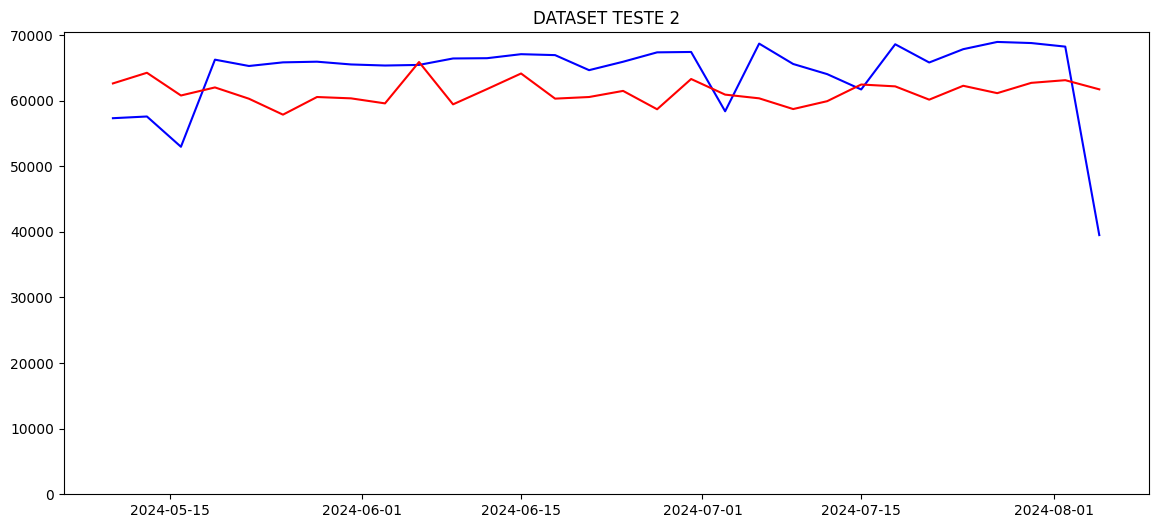

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_5.txt

Training with k-fold cross-validation, k=6


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - loss: 0.5942 - val_loss: 0.1439
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1585 - val_loss: 0.1893
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1587 - val_loss: 0.0957
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1526 - val_loss: 0.0856
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1475 - val_loss: 0.2135
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1567 - val_loss: 0.1434
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1416 - val_loss: 0.1739
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1385 - val_loss: 0.1521
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1455 - val_loss: 0.1375
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1410 - val_loss: 0.1439
Epoch 3/100000
20/20 ━━━━━━

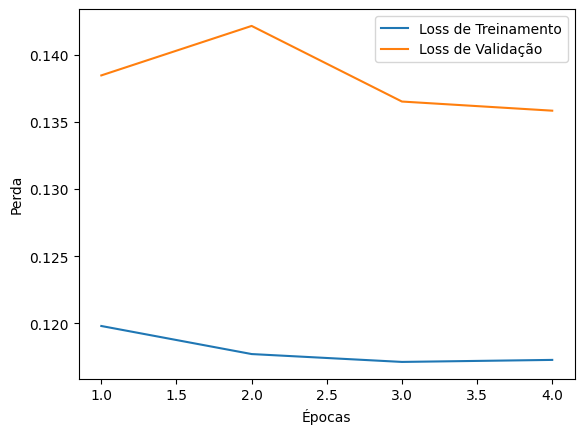

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - loss: 0.1351 - val_loss: 0.1879
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1328 - val_loss: 0.1172
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1231 - val_loss: 0.1195
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1198 - val_loss: 0.1451
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1230 - val_loss: 0.1155
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1217 - val_loss: 0.1373
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1196 - val_loss: 0.1474
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1214 - val_loss: 0.1301
Epoch 9/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1198 - val_loss: 0.1510
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1176 - val_loss: 0.1494
Epoch 2/100000
20/20 ━━━━

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 805ms/step - loss: 0.8800 - val_loss: 0.8356
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8342 - val_loss: 0.7891
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7873 - val_loss: 0.7288
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.7251 - val_loss: 0.6464
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.6397 - val_loss: 0.5366
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5271 - val_loss: 0.3985
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.3948 - val_loss: 0.2394
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2364 - val_loss: 0.0843
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1044 - val_loss: 0.0463
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0807 - val_loss: 0.0474
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0854 - val_l

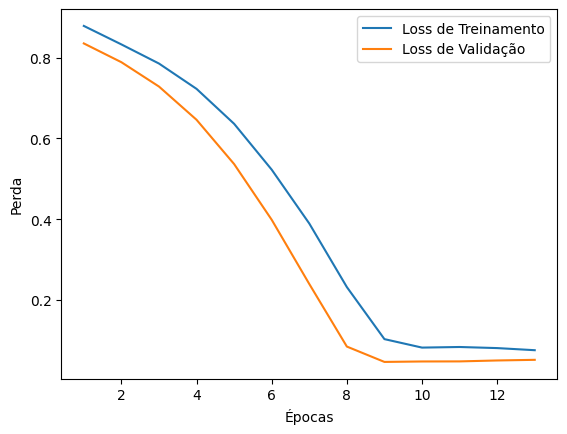

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step


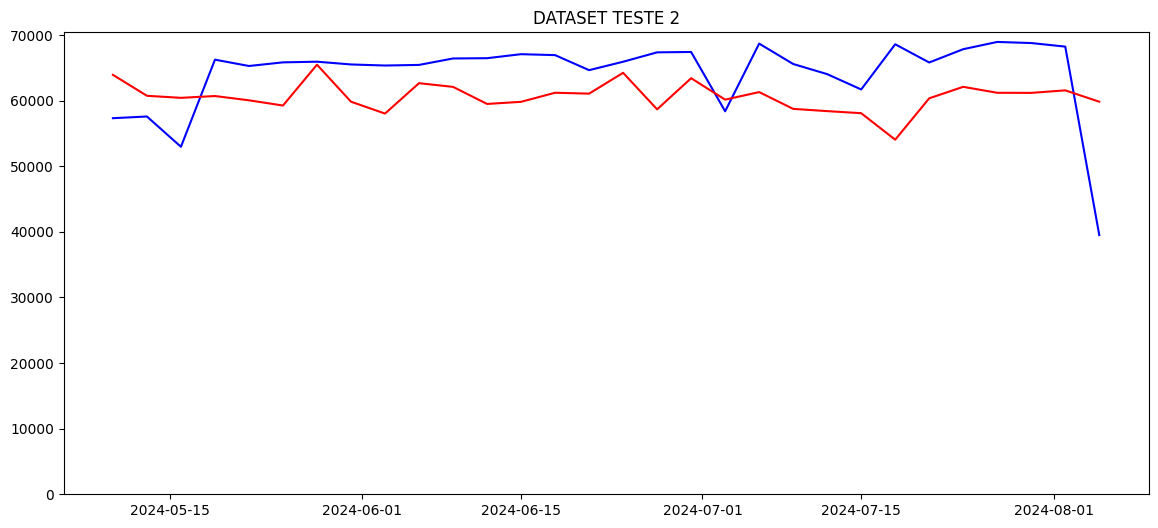

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_6.txt

Training with k-fold cross-validation, k=7


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.6031 - val_loss: 0.1300
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.1597 - val_loss: 0.0749
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1575 - val_loss: 0.0935
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1449 - val_loss: 0.0808
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1528 - val_loss: 0.0807
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1449 - val_loss: 0.0619
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1396 - val_loss: 0.0752
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1373 - val_loss: 0.0770
Epoch 9/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1370 - val_loss: 0.0569
Epoch 10/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1336 - val_loss: 0.0721
Epoch 11/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.1308 - val_loss: 0.0640
Epoch 12/100000
20/

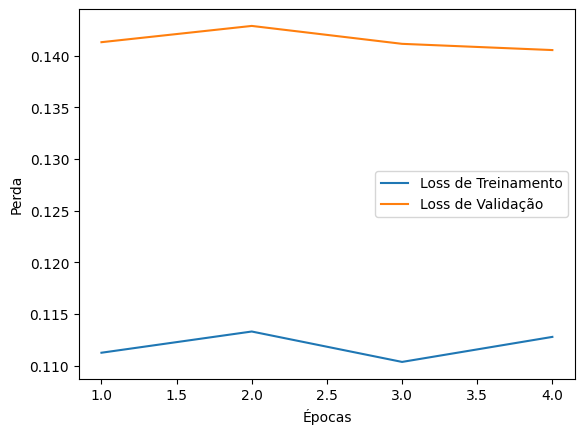

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss: 0.1197 - val_loss: 0.1033
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1214 - val_loss: 0.1028
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1161 - val_loss: 0.1019
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1167 - val_loss: 0.1038
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1187 - val_loss: 0.1021
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1182 - val_loss: 0.1037
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1197 - val_loss: 0.1027
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 3.
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1153 - val_loss: 0.1066
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1148 - val_loss: 0.1069
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1144 - val_loss: 0.1067
Epoch 4/100000
20/20 ━━━━━

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step - loss: 0.8800 - val_loss: 0.8348
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.8323 - val_loss: 0.7867
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.7836 - val_loss: 0.7239
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.7204 - val_loss: 0.6374
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6314 - val_loss: 0.5249
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.5183 - val_loss: 0.3792
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.3607 - val_loss: 0.2100
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1867 - val_loss: 0.0686
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0911 - val_loss: 0.0570
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0768 - val_loss: 0.0442
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0745 - val_l

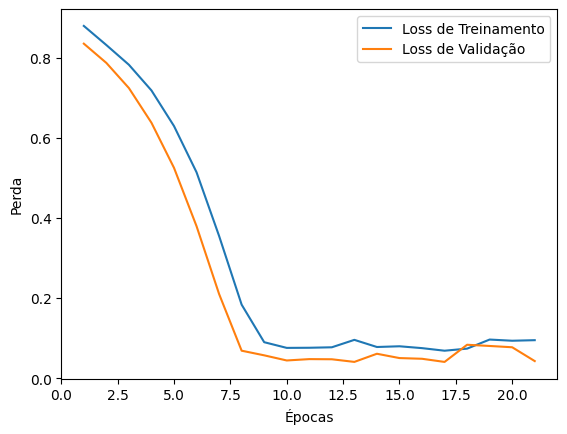

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step


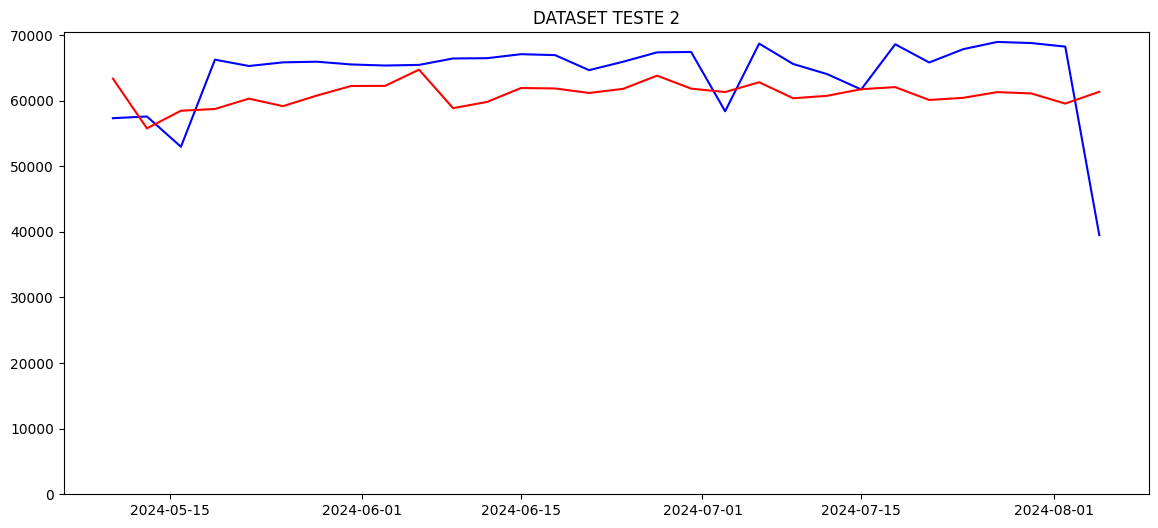

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_7.txt

Training with k-fold cross-validation, k=8


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.5928 - val_loss: 0.0938
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1572 - val_loss: 0.0587
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1490 - val_loss: 0.0619
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1440 - val_loss: 0.0610
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1443 - val_loss: 0.0628
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1424 - val_loss: 0.0763
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 2.
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1477 - val_loss: 0.0878
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1447 - val_loss: 0.0900
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1390 - val_loss: 0.0742
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1343 - val_loss: 0.0967
Epoch 4: early stopping
Res

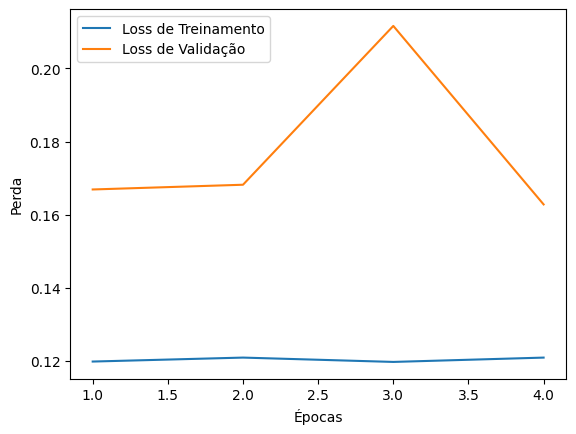

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 0.1373 - val_loss: 0.1045
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1208 - val_loss: 0.1061
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1204 - val_loss: 0.1070
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1162 - val_loss: 0.1029
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1153 - val_loss: 0.1022
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1152 - val_loss: 0.1024
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1146 - val_loss: 0.1025
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1176 - val_loss: 0.1027
Epoch 9/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1140 - val_loss: 0.1025
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1163 - val_loss: 0.1098
Epoch 2/100000
20/20 ━━━━━━

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 813ms/step - loss: 0.8803 - val_loss: 0.8354
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8336 - val_loss: 0.7884
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7857 - val_loss: 0.7278
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7217 - val_loss: 0.6435
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.6403 - val_loss: 0.5352
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.5214 - val_loss: 0.3974
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3770 - val_loss: 0.2353
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.2384 - val_loss: 0.0870
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0949 - val_loss: 0.0593
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0857 - val_loss: 0.0419
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0734 - val_l

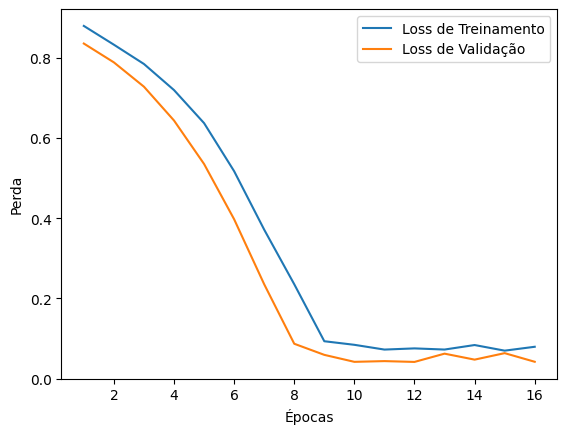

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step


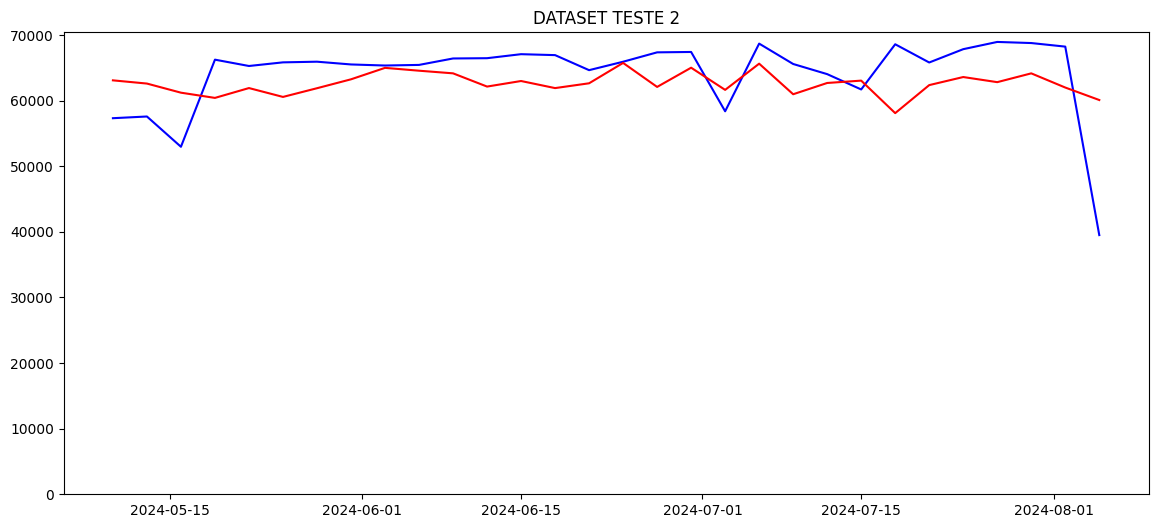

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_8.txt

Training with k-fold cross-validation, k=9


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.5900 - val_loss: 0.1393
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1567 - val_loss: 0.0844
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1476 - val_loss: 0.1025
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1469 - val_loss: 0.0880
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1359 - val_loss: 0.0633
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1376 - val_loss: 0.0925
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1364 - val_loss: 0.0922
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1316 - val_loss: 0.0837
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1349 - val_loss: 0.0858
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 5.
Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1441 - val_loss: 0.1462
Epoch 2/100000
21/21 ━━━━━━

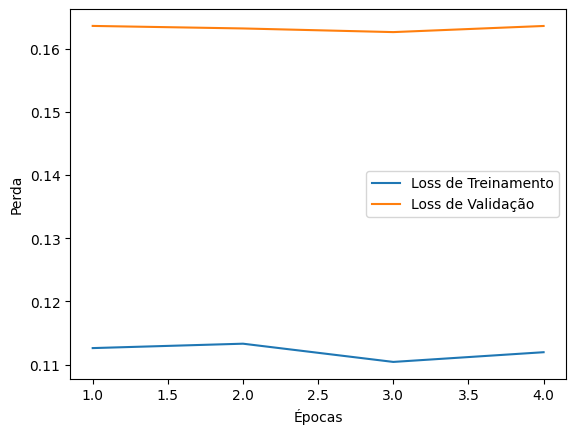

Epoch 1/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.1244 - val_loss: 0.1120
Epoch 2/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1170 - val_loss: 0.1068
Epoch 3/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1157 - val_loss: 0.1068
Epoch 4/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1172 - val_loss: 0.1097
Epoch 5/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1171 - val_loss: 0.1067
Epoch 6/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1147 - val_loss: 0.1096
Epoch 7/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1160 - val_loss: 0.1072
Epoch 8/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1143 - val_loss: 0.1076
Epoch 9/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.1168 - val_loss: 0.1063
Epoch 10/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1124 - val_loss: 0.1092
Epoch 11/100000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1122 - val_loss: 0.1246
Epoch 12/100000
21/

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.8803 - val_loss: 0.8381
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.8367 - val_loss: 0.7937
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.7912 - val_loss: 0.7362
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7358 - val_loss: 0.6581
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.6511 - val_loss: 0.5515
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.5398 - val_loss: 0.4141
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4017 - val_loss: 0.2513
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.2459 - val_loss: 0.0919
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0930 - val_loss: 0.0459
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0871 - val_loss: 0.0515
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0815 - val_los

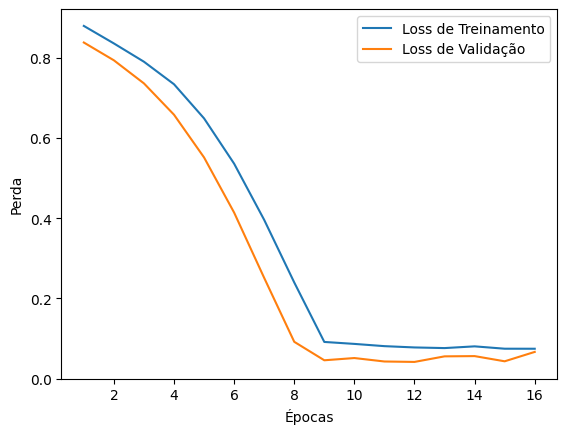

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step


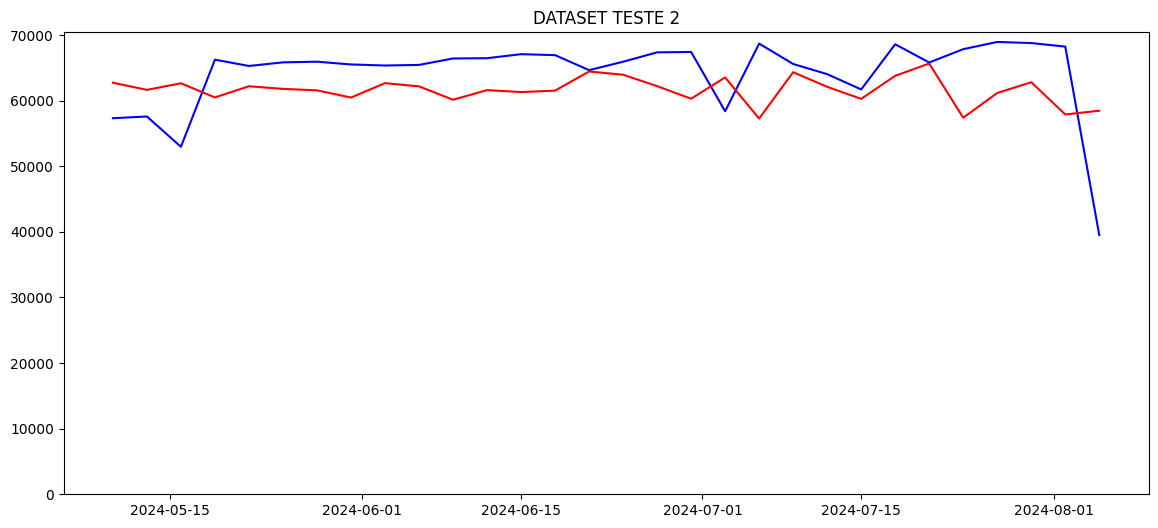

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_k-fold_9.txt

Training with train-test split


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_35 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

(1, 600)
(150, 600)
(600,)
LSTM 1 treinable:  False
Epoch 1/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - loss: 0.8793 - val_loss: 0.8335
Epoch 2/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.8314 - val_loss: 0.7799
Epoch 3/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.7757 - val_loss: 0.7052
Epoch 4/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.6962 - val_loss: 0.6005
Epoch 5/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.5909 - val_loss: 0.4542
Epoch 6/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.4433 - val_loss: 0.2742
Epoch 7/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2687 - val_loss: 0.0901
Epoch 8/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1111 - val_loss: 0.0573
Epoch 9/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0803 - val_loss: 0.0553
Epoch 10/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0971 - val_loss: 0.0470
Epoch 11/100000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0802 - val_

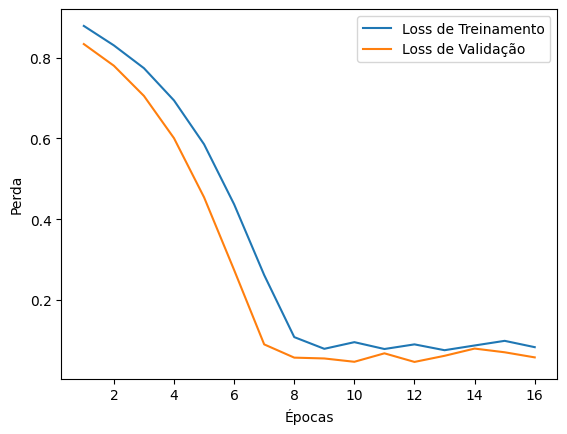

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step


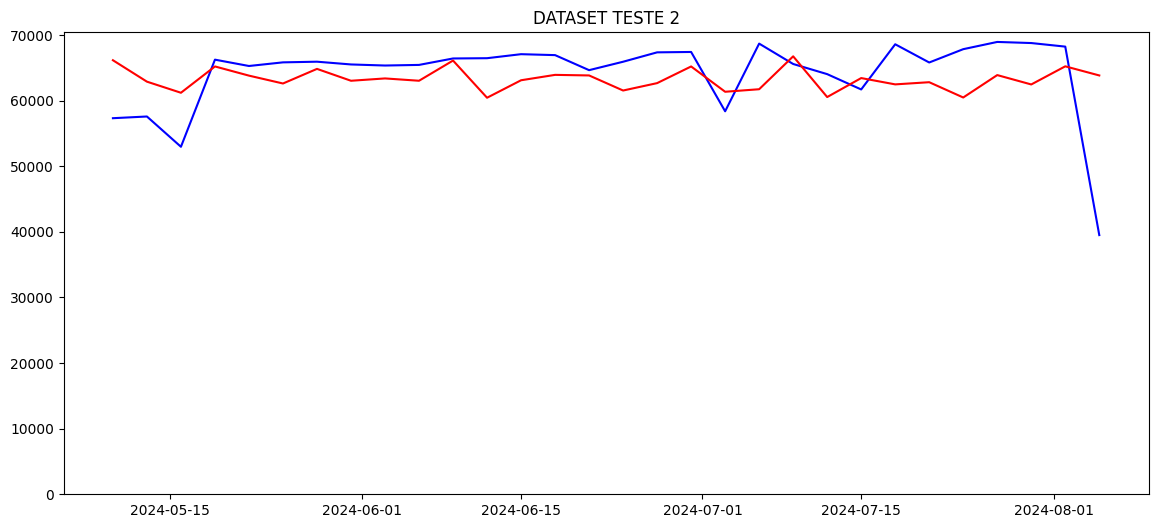

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3\avaliacao_with_method_split.txt


In [27]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
for k in range(2, 10):
    validation_method = 'k-fold'
    print(f"\nTraining with k-fold cross-validation, k={k}")
    model3 = train_model(X_3, y_3, validation_method, k=k)
    transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# Treinamento com train-test split
print("\nTraining with train-test split")
validation_method = 'split'
model3 = train_model(X_3, y_3, validation_method, 3)
transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, 'split')

In [28]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento3 = model3.get_weights()
# pesos_LSTM1_t3 = model3.layers[0].get_weights()
# pesos_LSTM2_t3 = model3.layers[2].get_weights()
# pesos_LSTM3_t3 = model3.layers[4].get_weights()
# pesos_DENSE_t3 = model3.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'), *pesos_LSTM1_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'), *pesos_LSTM2_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'), *pesos_LSTM3_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_DENSE_t3_{validation_method}.npz'), *pesos_DENSE_t3)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_modelo_t3_{validation_method}.npz'), *pesos_treinamento3)

In [29]:
# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'))
# pesos_carregados_LSTM2_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'))
# pesos_carregados_LSTM3_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'))

In [30]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model3_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model3_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model3_ft.add(Dropout(0.3))

# model3_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model3_ft.summary()

In [31]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz')
# caminho_LSTM2_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz')
# caminho_LSTM3_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz')

# carregar_e_aplicar_pesos(model3_ft, caminho_LSTM1_t3, caminho_LSTM2_t3, caminho_LSTM3_t3)

In [32]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t3[0], model3_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t3[1], model3_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t3[2], model3_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t3[0], model3_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t3[1], model3_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t3[2], model3_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# # ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t3[0], model3_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t3[1], model3_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t3[2], model3_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)

In [33]:
# congelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# descongelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [35]:
# pred = model3_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 3")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_3, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [36]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_3)

## **Teste 04**

Prata I, II, III, Pirapama e Duas Unas. Ações a serem testadas:

1. Padronizar cada dataset em separado (Prata I, II, III, Pirapama e Duas Unas);
2. Retirar do dataset Duas os dados de teste;
3. Concatenar os datasets;
4. Treinar o modelo com o novo dataset;
5. Validar o modelo com os dados de teste.

In [24]:
### DATASETS PARA TESTE 04 ###

indices = [0, 1, 2, 3, 4]
dataset_test_4 = concatenate_selected_datasets(scaled_datasets, indices)

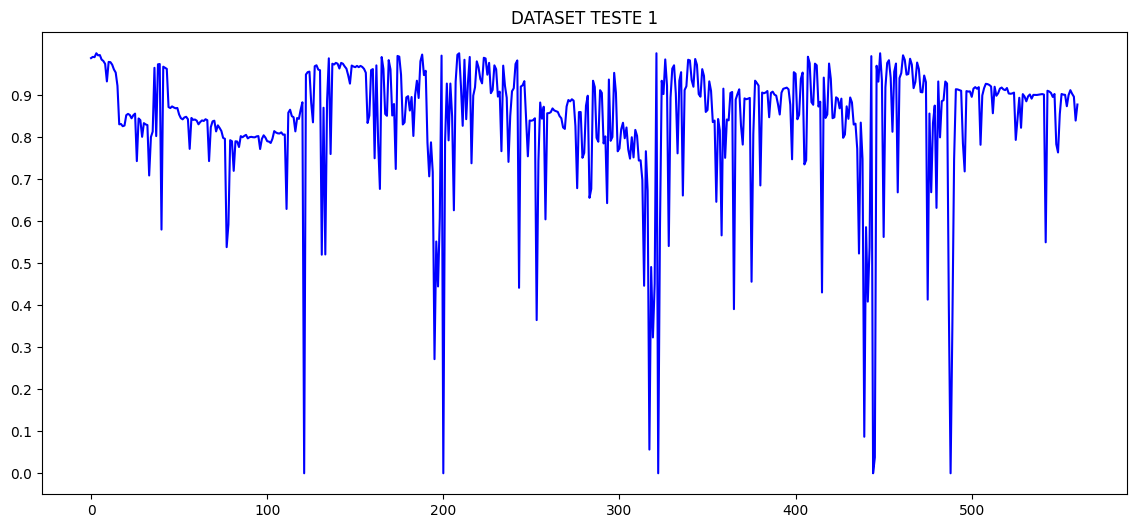

In [25]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_4, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

X shape (531, 1)
y shape (531, 30)


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.6875 - val_loss: 0.1529
Epoch 2/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.1676 - val_loss: 0.1064
Epoch 3/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1586 - val_loss: 0.1297
Epoch 4/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1621 - val_loss: 0.1009
Epoch 5/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1468 - val_loss: 0.1048
Epoch 6/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1496 - val_loss: 0.1021
Epoch 7/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1477 - val_loss: 0.0978
Epoch 8/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1453 - val_loss: 0.1187
Epoch 9/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1503 - val_loss: 0.1314
Epoch 10/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1473 - val_loss: 0.1498
Epoch 11/100000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1469 - val_loss: 0.1227
Epoch 11: early sto

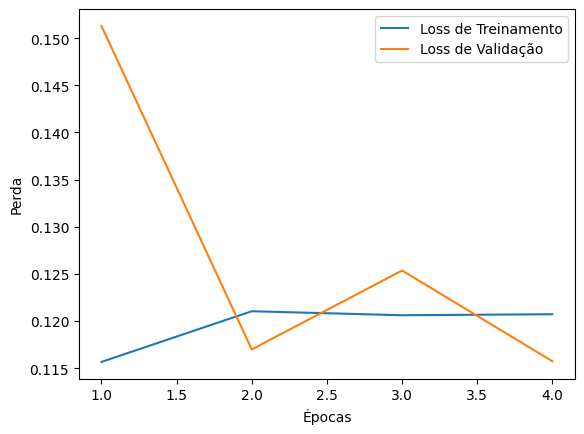

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step


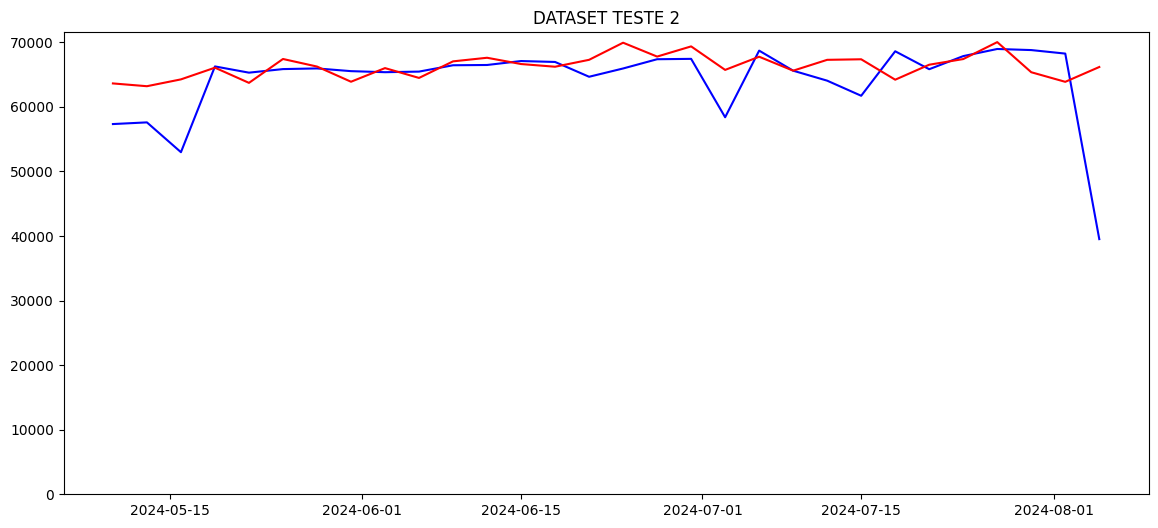

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_2.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 0.6321 - val_loss: 0.1178
Epoch 2/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1746 - val_loss: 0.1276
Epoch 3/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1625 - val_loss: 0.0924
Epoch 4/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1512 - val_loss: 0.0897
Epoch 5/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1477 - val_loss: 0.1111
Epoch 6/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1483 - val_loss: 0.0989
Epoch 7/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1429 - val_loss: 0.0969
Epoch 8/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1416 - val_loss: 0.0854
Epoch 9/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1380 - val_loss: 0.0986
Epoch 10/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1343 - val_loss: 0.0893
Epoch 11/100000
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1340 - val_loss: 0.0934
Epoch 12/100000
18/

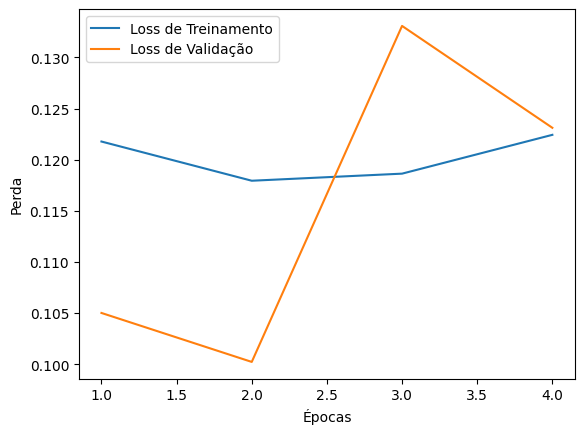

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step


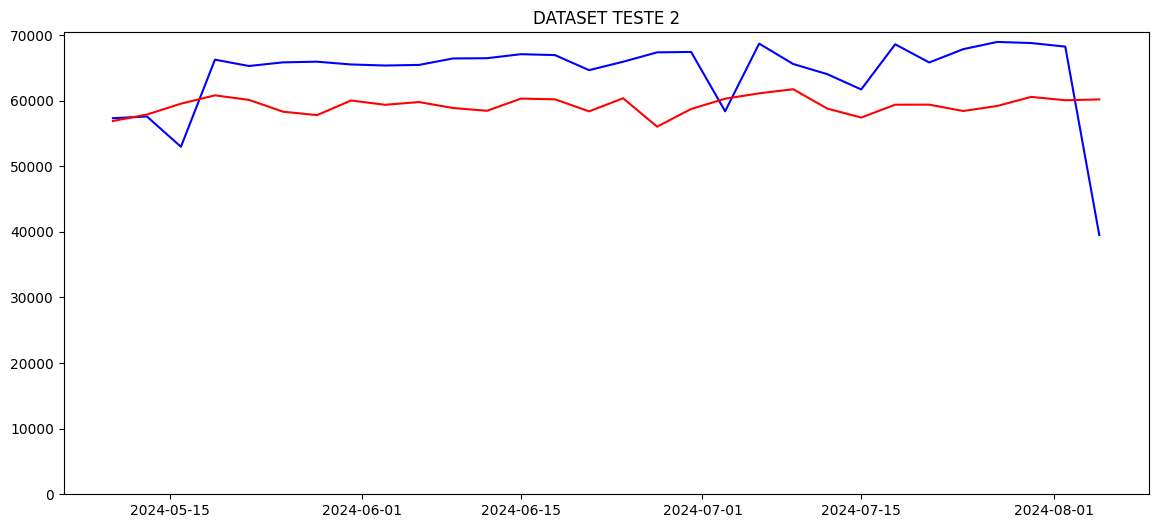

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_3.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.6092 - val_loss: 0.1096
Epoch 2/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1613 - val_loss: 0.1134
Epoch 3/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1583 - val_loss: 0.1291
Epoch 4/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1538 - val_loss: 0.1029
Epoch 5/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1401 - val_loss: 0.1052
Epoch 6/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1454 - val_loss: 0.0764
Epoch 7/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1345 - val_loss: 0.0747
Epoch 8/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1338 - val_loss: 0.0757
Epoch 9/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1349 - val_loss: 0.0770
Epoch 10/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1317 - val_loss: 0.0791
Epoch 11/100000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1267 - val_loss: 0.0817
Epoch 11: early sto

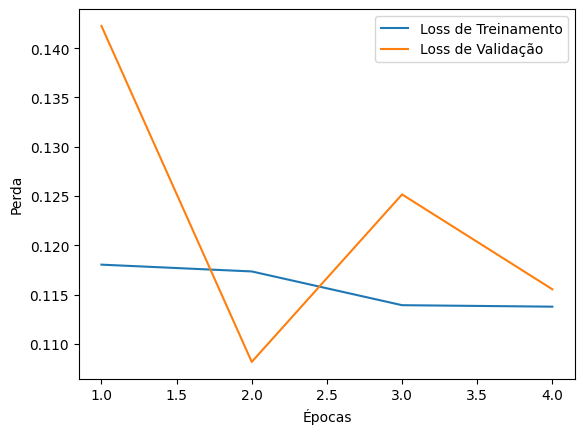

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step


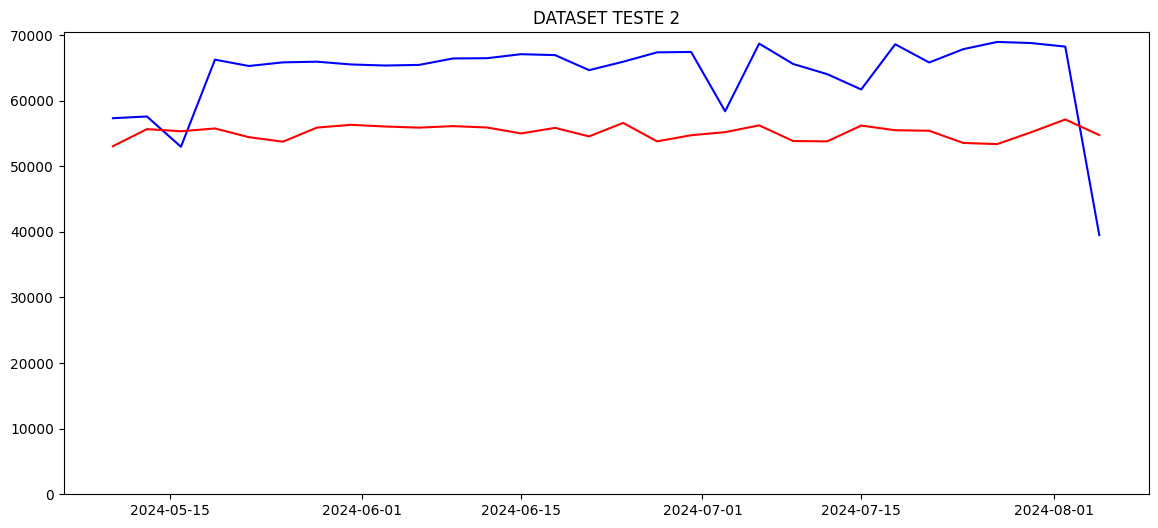

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_4.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.5821 - val_loss: 0.1076
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1636 - val_loss: 0.0716
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1466 - val_loss: 0.0684
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1427 - val_loss: 0.1414
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1465 - val_loss: 0.1837
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1457 - val_loss: 0.0662
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1339 - val_loss: 0.0939
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1302 - val_loss: 0.1004
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1288 - val_loss: 0.1146
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1288 - val_loss: 0.0588
Epoch 11/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1261 - val_loss: 0.1155
Epoch 12/100000
22/

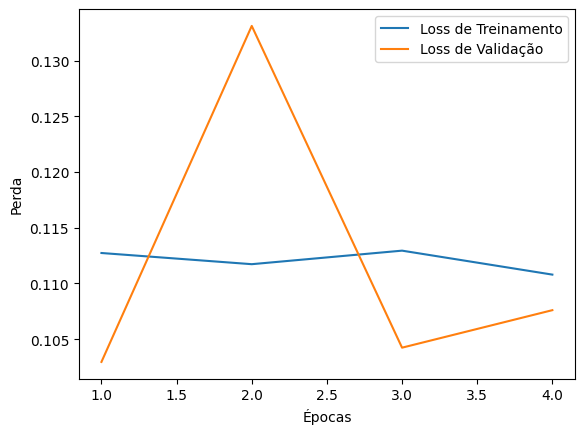

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step


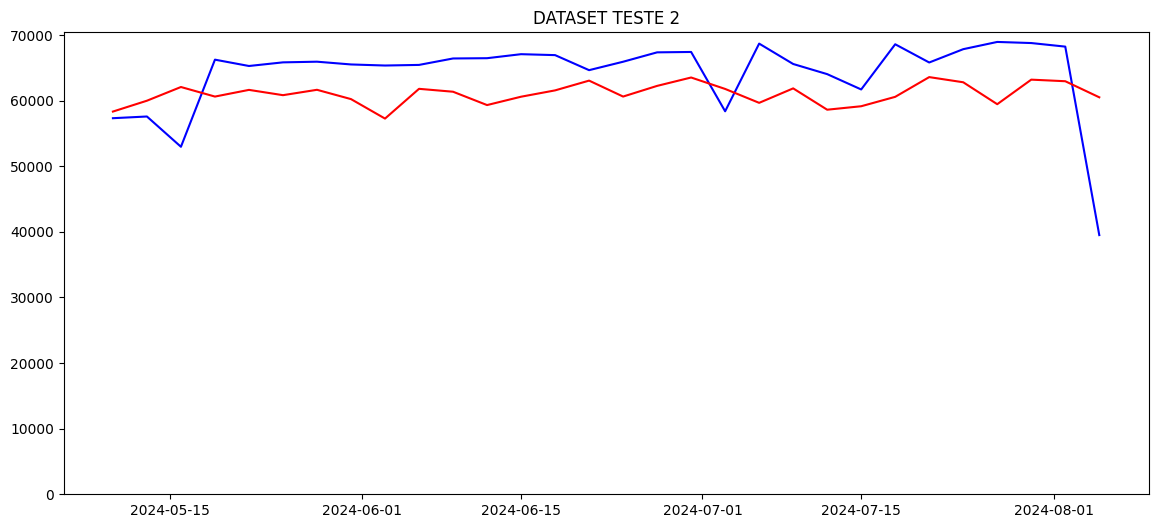

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_5.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 0.5742 - val_loss: 0.0870
Epoch 2/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1584 - val_loss: 0.1425
Epoch 3/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1589 - val_loss: 0.0719
Epoch 4/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1447 - val_loss: 0.0570
Epoch 5/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1426 - val_loss: 0.1129
Epoch 6/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1408 - val_loss: 0.1162
Epoch 7/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1451 - val_loss: 0.0741
Epoch 8/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1316 - val_loss: 0.0575
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1360 - val_loss: 0.1582
Epoch 2/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1380 - val_loss: 0.1523
Epoch 3/100000
23/23 ━━━━━━

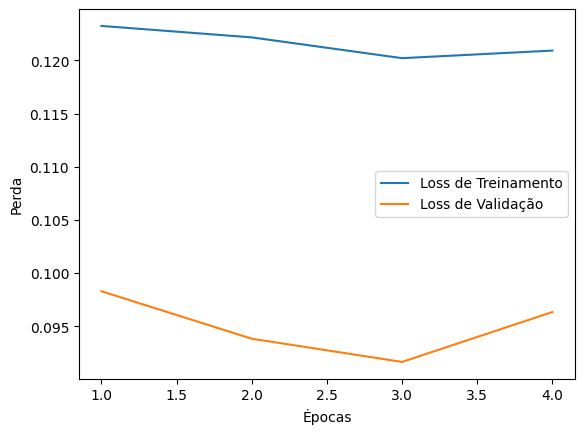

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


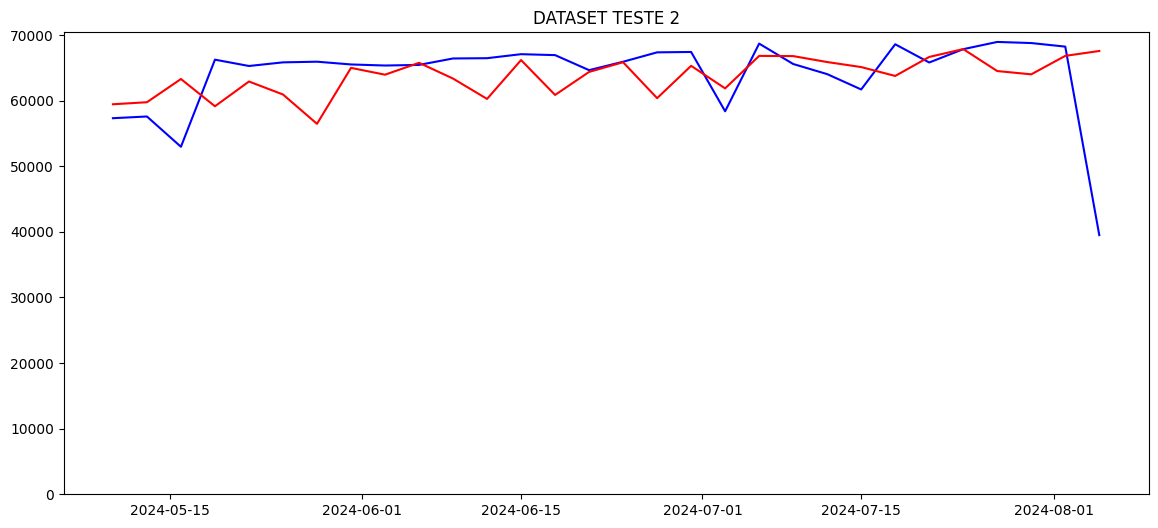

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_6.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.5582 - val_loss: 0.0830
Epoch 2/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1599 - val_loss: 0.1293
Epoch 3/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1518 - val_loss: 0.0873
Epoch 4/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1457 - val_loss: 0.0602
Epoch 5/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1400 - val_loss: 0.0901
Epoch 6/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1356 - val_loss: 0.1201
Epoch 7/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1374 - val_loss: 0.1007
Epoch 8/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1334 - val_loss: 0.0718
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 4.
Epoch 1/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1401 - val_loss: 0.1011
Epoch 2/100000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1290 - val_loss: 0.1084
Epoch 3/100000
23/23 ━━━━━━

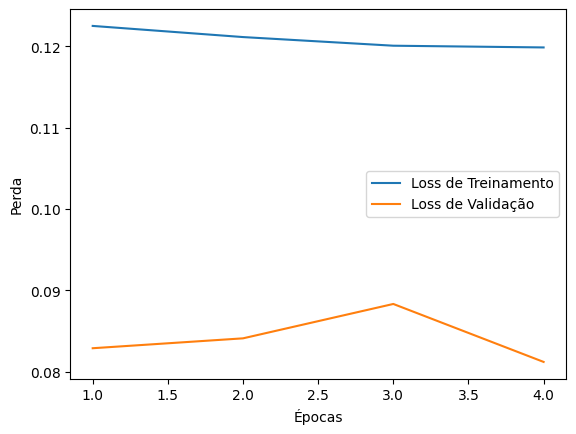

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


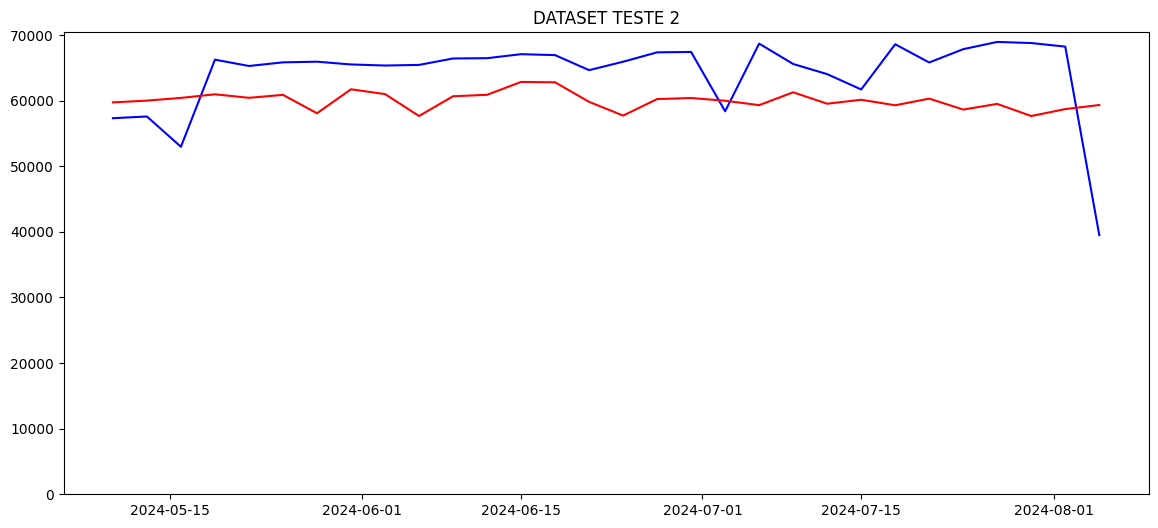

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_7.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.5527 - val_loss: 0.1544
Epoch 2/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1645 - val_loss: 0.1051
Epoch 3/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1589 - val_loss: 0.0663
Epoch 4/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1494 - val_loss: 0.0790
Epoch 5/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1450 - val_loss: 0.1016
Epoch 6/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1351 - val_loss: 0.0902
Epoch 7/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1297 - val_loss: 0.0616
Epoch 8/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1285 - val_loss: 0.1014
Epoch 9/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1324 - val_loss: 0.1003
Epoch 10/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1263 - val_loss: 0.0629
Epoch 11/100000
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1267 - val_loss: 0.0874
Epoch 11: early sto

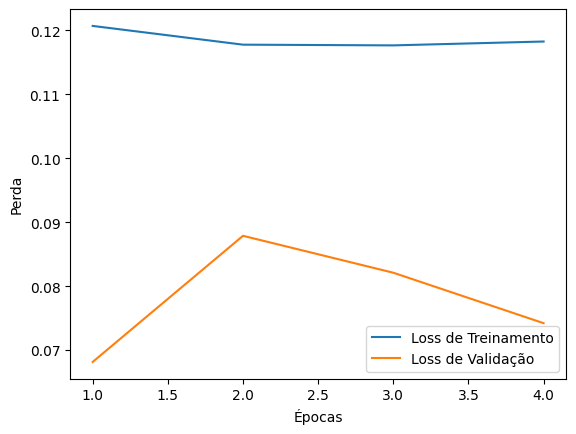

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step


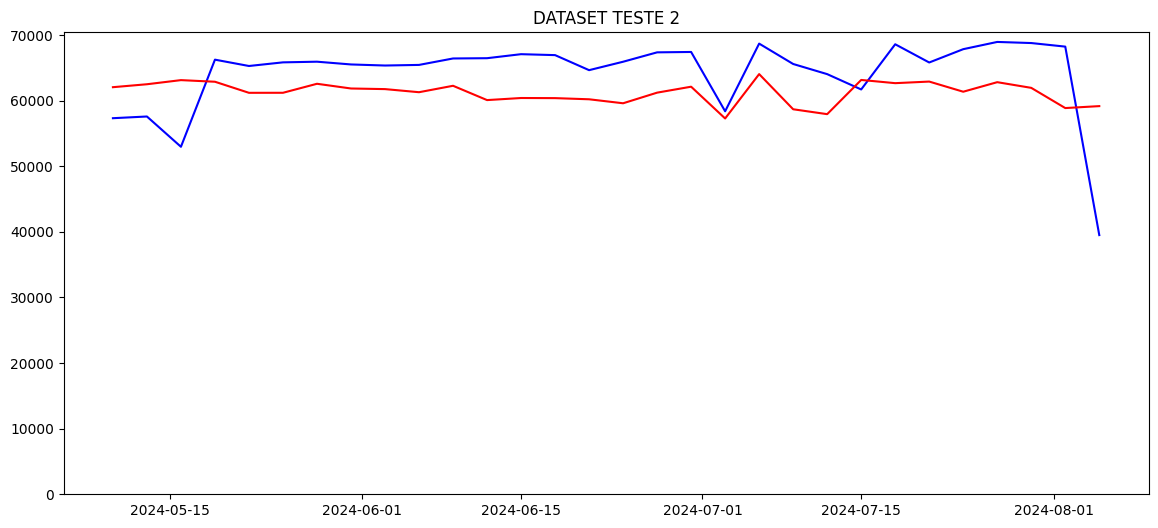

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_k-fold_8.txt


c:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 1, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1, 150)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │         4,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.5796 - val_loss: 0.2328
Epoch 2/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1579 - val_loss: 0.1179
Epoch 3/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1391 - val_loss: 0.1405
Epoch 4/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1359 - val_loss: 0.1174
Epoch 5/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1279 - val_loss: 0.1143
Epoch 6/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1303 - val_loss: 0.1648
Epoch 7/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1284 - val_loss: 0.1231
Epoch 8/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1264 - val_loss: 0.1177
Epoch 9/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1240 - val_loss: 0.1097
Epoch 10/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1164 - val_loss: 0.1165
Epoch 11/100000
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1187 - val_loss: 0.1275
Epoch 12/100000
22/

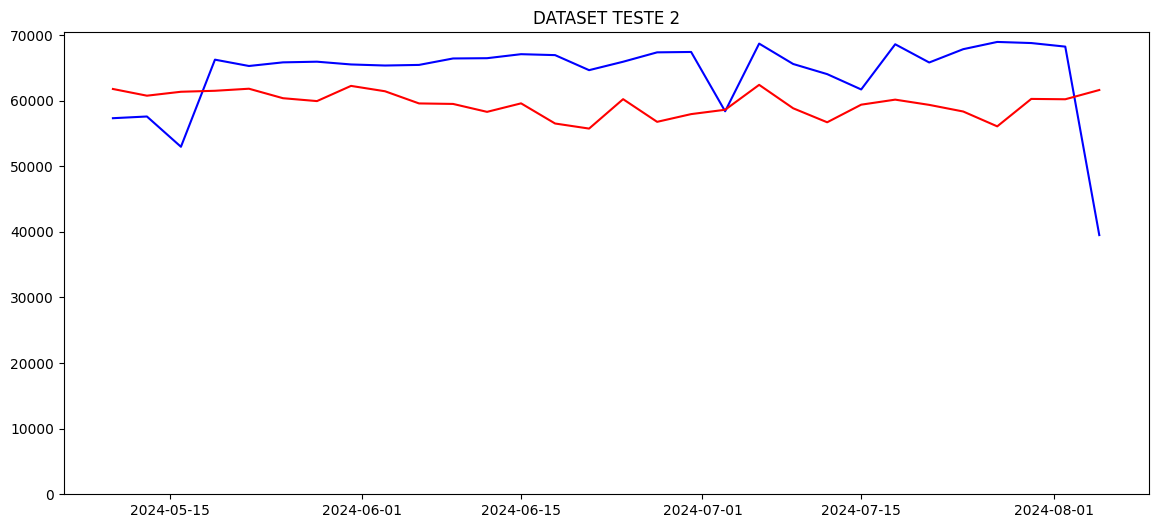

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_4\avaliacao_with_method_split.txt


In [26]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X, y = create_dataset(dataset_test_4, timesteps, output_steps)
X = X.reshape(X.shape[0], X.shape[1], 1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("X_train shape", np.array(X_train).shape)
# print("y_train shape", np.array(y_train).shape)
# print("X_test shape", np.array(X_test).shape)
# print("y_test shape", np.array(y_test).shape)

for k in range(2,9):
    model_4 = create_model(config, dataset_type_du, X, y, 'k-fold', k)
    results(model_4, duas_unas_validation_scaled, 'k-fold', diretorio_avaliacao_teste_4, k)

model_4 = create_model(config, dataset_type_du, X, y, 'split', 0)
results(model_4, duas_unas_validation_scaled, 'split', diretorio_avaliacao_teste_4, 'split')

#model_4 = create_model(config, dataset_type_du, X, y, validation_method, 5)